In [123]:
# ============================================================
# EXPLORATION DES SOURCES DE DONNÉES FAO
# Projet 11 — La Poule qui Chante
# ============================================================

import pandas as pd
import os

path = r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\DAN-P9-data"

In [124]:
df_fbs = pd.read_csv(os.path.join(path, "FoodBalanceSheets_E_All_Data_(Normalized).csv"), encoding='latin-1')
df_fs = pd.read_csv(os.path.join(path, "Food_Security_Data_E_All_Data_(Normalized).csv"), encoding='latin-1')
df_trade = pd.read_csv(os.path.join(path, "Trade_CropsLivestock_E_All_Data_(Normalized).csv"), encoding='latin-1', low_memory=False)
df_land = pd.read_csv(os.path.join(path, "Inputs_LandUse_E_All_Data_(Normalized).csv"), encoding='latin-1')
df_macro = pd.read_csv(os.path.join(path, "Macro-Statistics_Key_Indicators_E_All_Data_(Normalized).csv"), encoding='latin-1')
df_cost = pd.read_csv(os.path.join(path, "Cost_Affordability_Healthy_Diet_(CoAHD)_E_All_Data_(Normalized).csv"), encoding='latin-1')
df_temp = pd.read_csv(os.path.join(path, "Environment_Temperature_change_E_All_Data_(Normalized).csv"), encoding='latin-1')
df_wgi = pd.read_csv(os.path.join(path, "WGI_Data.csv"), encoding='latin-1')
df_wdi = pd.read_csv(os.path.join(path, "1e238a13-d177-4f2a-951c-15e2df6f995d_Data.csv"), encoding='latin-1')
df_wdi2 = pd.read_csv(os.path.join(path, "ff77f264-d347-4a04-b688-8795b69063ba_Data.csv"), encoding='latin-1')

print("✅ Tous les fichiers chargés !")

✅ Tous les fichiers chargés !


In [125]:
# Vérification des NaN dans chaque fichier
fichiers_fao = {
    "FoodBalanceSheets": df_fbs,
    "Food_Security": df_fs,
    "Trade": df_trade,
    "LandUse": df_land,
    "Macro": df_macro,
    "CoAHD": df_cost,
    "Temperature": df_temp
}

fichiers_wb = {
    "WGI": df_wgi,
    "WDI": df_wdi,
    "WDI_Growth": df_wdi2
}

print("=== FICHIERS FAO ===")
for nom, df in fichiers_fao.items():
    total = len(df)
    nan_value = df['Value'].isna().sum() if 'Value' in df.columns else None
    print(f"\n--- {nom} ---")
    print(f"Dimensions : {df.shape}")
    if nan_value is not None:
        print(f"NaN dans Value : {nan_value} ({round(nan_value/total*100, 1)}%)")

print("\n=== FICHIERS BANQUE MONDIALE ===")
for nom, df in fichiers_wb.items():
    print(f"\n--- {nom} ---")
    print(f"Dimensions : {df.shape}")
    print(f"NaN par colonne :")
    print(df.isnull().sum())
    

=== FICHIERS FAO ===

--- FoodBalanceSheets ---
Dimensions : (4820497, 14)
NaN dans Value : 0 (0.0%)

--- Food_Security ---
Dimensions : (279470, 13)
NaN dans Value : 38019 (13.6%)

--- Trade ---
Dimensions : (17270631, 14)
NaN dans Value : 0 (0.0%)

--- LandUse ---
Dimensions : (413211, 13)
NaN dans Value : 0 (0.0%)

--- Macro ---
Dimensions : (708632, 13)
NaN dans Value : 0 (0.0%)

--- CoAHD ---
Dimensions : (11672, 14)
NaN dans Value : 1207 (10.3%)

--- Temperature ---
Dimensions : (590512, 12)
NaN dans Value : 22333 (3.8%)

=== FICHIERS BANQUE MONDIALE ===

--- WGI ---
Dimensions : (1301, 14)
NaN par colonne :
Country Name     3
Country Code     5
Series Name      5
Series Code      5
2015 [YR2015]    5
2016 [YR2016]    5
2017 [YR2017]    5
2018 [YR2018]    5
2019 [YR2019]    5
2020 [YR2020]    5
2021 [YR2021]    5
2022 [YR2022]    5
2023 [YR2023]    5
2024 [YR2024]    5
dtype: int64

--- WDI ---
Dimensions : (1867, 9)
NaN par colonne :
Country Name     3
Country Code     5
Series 

In [126]:
# Identifier les agrégats régionaux dans FBS
pays_fbs = df_fbs['Area'].unique()

# Mots clés typiques des agrégats
keywords = ['world', 'africa', 'asia', 'europe', 'america', 'oceania', 
            'region', 'income', 'developed', 'developing', 'total',
            'eastern', 'western', 'northern', 'southern', 'central',
            'least', 'land', 'island', 'caribbean', 'pacific', 'atlantic']

agregats = [p for p in pays_fbs if any(k in p.lower() for k in keywords)]

print(f"Agrégats trouvés dans FBS : {len(agregats)}")
for a in sorted(agregats):
    print(' -', a)

Agrégats trouvés dans FBS : 45
 - Africa
 - Americas
 - Asia
 - Australia and New Zealand
 - Caribbean
 - Central America
 - Central Asia
 - China, mainland
 - Eastern Africa
 - Eastern Asia
 - Eastern Europe
 - Europe
 - European Union (27)
 - Finland
 - Iceland
 - Ireland
 - Land Locked Developing Countries (LLDCs)
 - Least Developed Countries (LDCs)
 - Low Income Food Deficit Countries (LIFDCs)
 - Marshall Islands
 - Middle Africa
 - Net Food Importing Developing Countries (NFIDCs)
 - Netherlands (Kingdom of the)
 - New Zealand
 - Northern Africa
 - Northern America
 - Northern Europe
 - Oceania
 - Poland
 - Small Island Developing States (SIDS)
 - Solomon Islands
 - South Africa
 - South America
 - South-eastern Asia
 - Southern Africa
 - Southern Asia
 - Southern Europe
 - Switzerland
 - Thailand
 - United Kingdom of Great Britain and Northern Ireland
 - United States of America
 - Western Africa
 - Western Asia
 - Western Europe
 - World


In [127]:
# Agrégats UNIQUEMENT - liste manuelle précise
agregats_a_supprimer = [
    'Africa', 'Americas', 'Asia', 'Europe', 'Oceania', 'World',
    'Caribbean', 'Central America', 'South America', 'Northern America',
    'Central Asia', 'Eastern Asia', 'South-eastern Asia', 'Southern Asia',
    'Western Asia', 'Eastern Africa', 'Middle Africa', 'Northern Africa',
    'Southern Africa', 'Western Africa', 'Eastern Europe', 'Northern Europe',
    'Southern Europe', 'Western Europe', 'Australia and New Zealand',
    'European Union (27)',
    'Land Locked Developing Countries (LLDCs)',
    'Least Developed Countries (LDCs)',
    'Low Income Food Deficit Countries (LIFDCs)',
    'Net Food Importing Developing Countries (NFIDCs)',
    'Small Island Developing States (SIDS)'
]

print(f"Nombre d'agrégats à supprimer : {len(agregats_a_supprimer)}")
print(f"\nVrais pays conservés parmi les détectés :")
vrais_pays = [p for p in agregats if p not in agregats_a_supprimer]
for p in sorted(vrais_pays):
    print(' -', p)

Nombre d'agrégats à supprimer : 31

Vrais pays conservés parmi les détectés :
 - China, mainland
 - Finland
 - Iceland
 - Ireland
 - Marshall Islands
 - Netherlands (Kingdom of the)
 - New Zealand
 - Poland
 - Solomon Islands
 - South Africa
 - Switzerland
 - Thailand
 - United Kingdom of Great Britain and Northern Ireland
 - United States of America


In [128]:
# ============================================================
# LISTE DES AGRÉGATS RÉGIONAUX SUPPRIMÉS
# Raison : ce ne sont pas des pays, ils fausseraient l'analyse
# ============================================================

agregats_a_supprimer = [
    # Continents et grandes régions
    'World',
    'Africa',
    'Americas',
    'Asia',
    'Europe',
    'Oceania',

    # Sous-régions géographiques
    'Caribbean',
    'Central America',
    'South America',
    'Northern America',
    'Central Asia',
    'Eastern Asia',
    'South-eastern Asia',
    'Southern Asia',
    'Western Asia',
    'Eastern Africa',
    'Middle Africa',
    'Northern Africa',
    'Southern Africa',
    'Western Africa',
    'Eastern Europe',
    'Northern Europe',
    'Southern Europe',
    'Western Europe',
    'Australia and New Zealand',

    # Groupes économiques
    'European Union (27)',
    'Land Locked Developing Countries (LLDCs)',
    'Least Developed Countries (LDCs)',
    'Low Income Food Deficit Countries (LIFDCs)',
    'Net Food Importing Developing Countries (NFIDCs)',
    'Small Island Developing States (SIDS)'
]

print(f"✅ {len(agregats_a_supprimer)} agrégats identifiés et supprimés")

✅ 31 agrégats identifiés et supprimés


In [129]:
# ============================================================
# SUPPRESSION DES AGRÉGATS RÉGIONAUX
# ============================================================

df_fbs_clean = df_fbs[~df_fbs['Area'].isin(agregats_a_supprimer)]
df_fs_clean = df_fs[~df_fs['Area'].isin(agregats_a_supprimer)]
df_trade_clean = df_trade[~df_trade['Area'].isin(agregats_a_supprimer)]
df_land_clean = df_land[~df_land['Area'].isin(agregats_a_supprimer)]
df_macro_clean = df_macro[~df_macro['Area'].isin(agregats_a_supprimer)]
df_cost_clean = df_cost[~df_cost['Area'].isin(agregats_a_supprimer)]
df_temp_clean = df_temp[~df_temp['Area'].isin(agregats_a_supprimer)]

print("=== PAYS RESTANTS APRÈS SUPPRESSION AGRÉGATS ===")
print(f"FoodBalanceSheets : {df_fbs_clean['Area'].nunique()} pays")
print(f"Food_Security     : {df_fs_clean['Area'].nunique()} pays")
print(f"Trade             : {df_trade_clean['Area'].nunique()} pays")
print(f"LandUse           : {df_land_clean['Area'].nunique()} pays")
print(f"Macro             : {df_macro_clean['Area'].nunique()} pays")
print(f"CoAHD             : {df_cost_clean['Area'].nunique()} pays")
print(f"Temperature       : {df_temp_clean['Area'].nunique()} pays")

=== PAYS RESTANTS APRÈS SUPPRESSION AGRÉGATS ===
FoodBalanceSheets : 182 pays
Food_Security     : 221 pays
Trade             : 252 pays
LandUse           : 253 pays
Macro             : 221 pays
CoAHD             : 219 pays
Temperature       : 257 pays


In [130]:
# Pays disponibles en 2017 dans chaque fichier FAO
pays_fbs = set(df_fbs_clean[df_fbs_clean['Year'] == 2017]['Area'].unique())
pays_fs = set(df_fs_clean[df_fs_clean['Year'] == '2017']['Area'].unique())
pays_trade = set(df_trade_clean[df_trade_clean['Year'] == 2017]['Area'].unique())
pays_land = set(df_land_clean[df_land_clean['Year'] == 2017]['Area'].unique())
pays_macro = set(df_macro_clean[df_macro_clean['Year'] == 2017]['Area'].unique())
pays_cost = set(df_cost_clean[df_cost_clean['Year'] == 2017]['Area'].unique())

print("Pays disponibles en 2017 par source FAO :")
print(f"FoodBalanceSheets : {len(pays_fbs)} pays")
print(f"Food_Security     : {len(pays_fs)} pays")
print(f"Trade             : {len(pays_trade)} pays")
print(f"LandUse           : {len(pays_land)} pays")
print(f"Macro             : {len(pays_macro)} pays")
print(f"CoAHD             : {len(pays_cost)} pays")

# Intersection de tous les fichiers FAO
intersection = pays_fbs & pays_fs & pays_trade & pays_land & pays_macro & pays_cost
print(f"\n✅ Pays présents dans TOUS les fichiers FAO : {len(intersection)} pays")

Pays disponibles en 2017 par source FAO :
FoodBalanceSheets : 174 pays
Food_Security     : 221 pays
Trade             : 236 pays
LandUse           : 244 pays
Macro             : 213 pays
CoAHD             : 219 pays

✅ Pays présents dans TOUS les fichiers FAO : 169 pays


In [131]:
# Vérification de la couverture population mondiale
# On utilise FBS pour la population 2017
df_pop = df_fbs_clean[
    (df_fbs_clean['Year'] == 2017) & 
    (df_fbs_clean['Item'] == 'Population') & 
    (df_fbs_clean['Element'] == 'Total Population - Both sexes')
][['Area', 'Value']].rename(columns={'Value': 'Population'})

# Population totale mondiale dans notre fichier
pop_mondiale = df_pop['Population'].sum()

# Population des 169 pays de l'intersection
pop_intersection = df_pop[df_pop['Area'].isin(intersection)]['Population'].sum()

# Couverture
couverture = round(pop_intersection / pop_mondiale * 100, 1)

print(f"Population mondiale dans FBS : {round(pop_mondiale/1000, 1)} milliards")
print(f"Population des 169 pays      : {round(pop_intersection/1000, 1)} milliards")
print(f"Couverture population        : {couverture}%")
print()
if couverture >= 60:
    print("✅ Objectif 60% population mondiale atteint !")
else:
    print("❌ Objectif 60% non atteint — il faut revoir la stratégie")

Population mondiale dans FBS : 8798.5 milliards
Population des 169 pays      : 7318.9 milliards
Couverture population        : 83.2%

✅ Objectif 60% population mondiale atteint !


In [132]:
# Extraire les pays WGI
pays_wgi = set(df_wgi[df_wgi['Country Name'].notna()]['Country Name'].unique())

# Comparer avec l'intersection FAO
pays_communs = intersection & pays_wgi
pays_fao_manquants = intersection - pays_wgi
pays_wb_manquants = pays_wgi - intersection

print(f"Pays FAO dans l'intersection : {len(intersection)}")
print(f"Pays WGI disponibles : {len(pays_wgi)}")
print(f"Pays en commun : {len(pays_communs)}")
print(f"\nPays FAO non trouvés dans WGI : {len(pays_fao_manquants)}")
for p in sorted(pays_fao_manquants):
    print(' -', p)

Pays FAO dans l'intersection : 169
Pays WGI disponibles : 218
Pays en commun : 142

Pays FAO non trouvés dans WGI : 27
 - Bahamas
 - Bolivia (Plurinational State of)
 - China, Hong Kong SAR
 - China, Macao SAR
 - China, mainland
 - Congo
 - CÃ´te d'Ivoire
 - Democratic People's Republic of Korea
 - Democratic Republic of the Congo
 - Egypt
 - Gambia
 - Iran (Islamic Republic of)
 - Kyrgyzstan
 - Lao People's Democratic Republic
 - Netherlands (Kingdom of the)
 - Republic of Korea
 - Republic of Moldova
 - Saint Kitts and Nevis
 - Saint Lucia
 - Saint Vincent and the Grenadines
 - Slovakia
 - TÃ¼rkiye
 - United Kingdom of Great Britain and Northern Ireland
 - United Republic of Tanzania
 - United States of America
 - Venezuela (Bolivarian Republic of)
 - Yemen


In [133]:
print("=== CODES DANS FAO ===")
print(df_fbs_clean[['Area', 'Area Code']].drop_duplicates().head(10).to_string())

print()
print("=== CODES DANS WGI ===")
print(df_wgi[['Country Name', 'Country Code']].dropna().head(10).to_string())

=== CODES DANS FAO ===
                   Area  Area Code
0           Afghanistan          2
1               Albania          3
5               Algeria          4
8                Angola          7
14  Antigua and Barbuda          8
18            Argentina          9
25              Armenia          1
30            Australia         10
44              Austria         11
48           Azerbaijan         52

=== CODES DANS WGI ===
  Country Name Country Code
0  Afghanistan          AFG
1  Afghanistan          AFG
2  Afghanistan          AFG
3  Afghanistan          AFG
4  Afghanistan          AFG
5  Afghanistan          AFG
6      Albania          ALB
7      Albania          ALB
8      Albania          ALB
9      Albania          ALB


In [134]:
# Chargement du fichier AreaCodes FAO
df_areas = pd.read_csv(os.path.join(path, "FoodBalanceSheets_E_AreaCodes.csv"), encoding='latin-1')

print("=== APERCU AREACODES ===")
print(df_areas.head(10).to_string())
print()
print("=== COLONNES ===")
print(list(df_areas.columns))

=== APERCU AREACODES ===
   Area Code M49 Code         Area
0          2     '004  Afghanistan
1          2     '004  Afghanistan
2       5100     '002       Africa
3       5100     '002       Africa
4          3     '008      Albania
5          3     '008      Albania
6          4     '012      Algeria
7          4     '012      Algeria
8       5200     '019     Americas
9       5200     '019     Americas

=== COLONNES ===
[' Area Code', ' M49 Code', ' Area']


In [135]:
import subprocess
subprocess.run(['pip', 'install', 'pycountry'], capture_output=True)
import pycountry
print("✅ pycountry installé !")

✅ pycountry installé !


In [136]:
# Test de conversion nom → ISO3
def get_iso3(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except:
        return None

# Test sur quelques pays FAO
test_pays = ['Afghanistan', 'France', 'United States of America', 
             'Bolivia (Plurinational State of)', 'Egypt']

for p in test_pays:
    iso3 = get_iso3(p)
    print(f"{p} → {iso3}")

Afghanistan → AFG
France → FRA
United States of America → USA
Bolivia (Plurinational State of) → None
Egypt → EGY


In [137]:
import subprocess
subprocess.run(['pip', 'install', 'thefuzz'], capture_output=True)
from thefuzz import process
import pycountry

def get_iso3_fuzzy(country_name):
    # Essai direct
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except:
        pass
    
    # Essai fuzzy matching
    try:
        pays_list = [c.name for c in pycountry.countries]
        best_match, score = process.extractOne(country_name, pays_list)
        if score >= 80:
            return pycountry.countries.lookup(best_match).alpha_3
        return None
    except:
        return None

# Test sur les pays problématiques
test_pays = [
    'Bolivia (Plurinational State of)',
    'China, mainland',
    'Congo',
    'Democratic Republic of the Congo',
    'Iran (Islamic Republic of)',
    'Netherlands (Kingdom of the)',
    'United States of America',
    'Venezuela (Bolivarian Republic of)'
]

for p in test_pays:
    iso3 = get_iso3_fuzzy(p)
    print(f"{p} → {iso3}")

Bolivia (Plurinational State of) → BOL
China, mainland → CHN
Congo → COG
Democratic Republic of the Congo → COD
Iran (Islamic Republic of) → IRN
Netherlands (Kingdom of the) → NLD
United States of America → USA
Venezuela (Bolivarian Republic of) → VEN


In [138]:
# Créer une table de correspondance Nom FAO → ISO3
print("Création de la table de correspondance...")

correspondance_fao_iso3 = {}
pays_sans_iso3 = []

for pays in sorted(intersection):
    iso3 = get_iso3_fuzzy(pays)
    if iso3:
        correspondance_fao_iso3[pays] = iso3
    else:
        pays_sans_iso3.append(pays)

print(f"✅ Pays avec ISO3 trouvé : {len(correspondance_fao_iso3)}")
print(f"❌ Pays sans ISO3 : {len(pays_sans_iso3)}")
print()
if pays_sans_iso3:
    print("Pays sans correspondance ISO3 :")
    for p in pays_sans_iso3:
        print(f" - {p}")

Création de la table de correspondance...
✅ Pays avec ISO3 trouvé : 169
❌ Pays sans ISO3 : 0



In [139]:
# Ajouter la colonne ISO3 aux pays FAO
# Vérifier la correspondance avec WGI

# Créer une Series de correspondance
fao_to_iso3 = pd.Series(correspondance_fao_iso3)

# Pays WGI disponibles en ISO3
pays_wgi_iso3 = set(df_wgi['Country Code'].dropna().unique())

# Pays FAO en ISO3
pays_fao_iso3 = set(correspondance_fao_iso3.values())

# Intersection
communs = pays_fao_iso3 & pays_wgi_iso3
manquants_wgi = pays_fao_iso3 - pays_wgi_iso3

print(f"Pays FAO en ISO3 : {len(pays_fao_iso3)}")
print(f"Pays WGI en ISO3 : {len(pays_wgi_iso3)}")
print(f"Pays en commun   : {len(communs)}")
print(f"\nPays FAO non trouvés dans WGI : {len(manquants_wgi)}")
for p in sorted(manquants_wgi):
    print(f" - {p}")

Pays FAO en ISO3 : 167
Pays WGI en ISO3 : 216
Pays en commun   : 167

Pays FAO non trouvés dans WGI : 0


In [140]:
# Vérifier correspondance avec WDI et WDI_Growth
pays_wdi_iso3 = set(df_wdi['Country Code'].dropna().unique())
pays_wdi2_iso3 = set(df_wdi2['Country Code'].dropna().unique())

communs_wdi = pays_fao_iso3 & pays_wdi_iso3
communs_wdi2 = pays_fao_iso3 & pays_wdi2_iso3

manquants_wdi = pays_fao_iso3 - pays_wdi_iso3
manquants_wdi2 = pays_fao_iso3 - pays_wdi2_iso3

print(f"=== WDI ===")
print(f"Pays en commun   : {len(communs_wdi)}")
print(f"Pays manquants   : {len(manquants_wdi)}")
for p in sorted(manquants_wdi):
    print(f" - {p}")

print(f"\n=== WDI_Growth ===")
print(f"Pays en commun   : {len(communs_wdi2)}")
print(f"Pays manquants   : {len(manquants_wdi2)}")
for p in sorted(manquants_wdi2):
    print(f" - {p}")

=== WDI ===
Pays en commun   : 167
Pays manquants   : 0

=== WDI_Growth ===
Pays en commun   : 167
Pays manquants   : 0


In [141]:
# ============================================================
# EXTRACTION DES VARIABLES — FoodBalanceSheets
# Variables retenues :
# - Poultry Meat : Import quantity, Production, Food supply (kcal/capita/day)
# - Pigmeat : Food supply quantity (kg/capita/yr)
# - Meat : Food supply quantity (kg/capita/yr)
# - Population : Total Population - Both sexes
# ============================================================

# Filtrer sur 2017 uniquement
df_fbs_2017 = df_fbs_clean[df_fbs_clean['Year'] == 2017]

# Extraction Poultry Meat
poultry_import = df_fbs_2017[
    (df_fbs_2017['Item'] == 'Poultry Meat') & 
    (df_fbs_2017['Element'] == 'Import quantity')
][['Area', 'Value']].rename(columns={'Value': 'poultry_import_qty'})

poultry_production = df_fbs_2017[
    (df_fbs_2017['Item'] == 'Poultry Meat') & 
    (df_fbs_2017['Element'] == 'Production')
][['Area', 'Value']].rename(columns={'Value': 'poultry_production'})

poultry_food_supply = df_fbs_2017[
    (df_fbs_2017['Item'] == 'Poultry Meat') & 
    (df_fbs_2017['Element'] == 'Food supply (kcal/capita/day)')
][['Area', 'Value']].rename(columns={'Value': 'poultry_kcal_capita'})

# Extraction Pigmeat
pigmeat_supply = df_fbs_2017[
    (df_fbs_2017['Item'] == 'Pigmeat') & 
    (df_fbs_2017['Element'] == 'Food supply quantity (kg/capita/yr)')
][['Area', 'Value']].rename(columns={'Value': 'pigmeat_kg_capita'})

# Extraction Meat total
meat_supply = df_fbs_2017[
    (df_fbs_2017['Item'] == 'Meat') & 
    (df_fbs_2017['Element'] == 'Food supply quantity (kg/capita/yr)')
][['Area', 'Value']].rename(columns={'Value': 'meat_total_kg_capita'})

# Extraction Population
population = df_fbs_2017[
    (df_fbs_2017['Item'] == 'Population') & 
    (df_fbs_2017['Element'] == 'Total Population - Both sexes')
][['Area', 'Value']].rename(columns={'Value': 'population'})

# Extraction Food supply total
food_supply_kcal = df_fbs_2017[
    (df_fbs_2017['Item'] == 'Grand Total') & 
    (df_fbs_2017['Element'] == 'Food supply (kcal/capita/day)')
][['Area', 'Value']].rename(columns={'Value': 'food_supply_kcal_capita'})

print("=== EXTRACTION FBS ===")
print(f"poultry_import_qty    : {len(poultry_import)} pays")
print(f"poultry_production    : {len(poultry_production)} pays")
print(f"poultry_kcal_capita   : {len(poultry_food_supply)} pays")
print(f"pigmeat_kg_capita     : {len(pigmeat_supply)} pays")
print(f"meat_total_kg_capita  : {len(meat_supply)} pays")
print(f"population            : {len(population)} pays")
print(f"food_supply_kcal      : {len(food_supply_kcal)} pays")

=== EXTRACTION FBS ===
poultry_import_qty    : 173 pays
poultry_production    : 172 pays
poultry_kcal_capita   : 174 pays
pigmeat_kg_capita     : 171 pays
meat_total_kg_capita  : 174 pays
population            : 174 pays
food_supply_kcal      : 174 pays


In [142]:
# ============================================================
# EXTRACTION DES VARIABLES — Food Security
# Variables retenues :
# - GDP per capita PPP
# - Average supply of protein of animal origin
# - Prevalence of unaffordability (PUA)
# - Rail lines density
# - Value of food imports in total merchandise exports
# ============================================================

# Filtrer sur 2017
df_fs_2017 = df_fs_clean[df_fs_clean['Year'] == '2017']

# GDP per capita PPP
gdp_per_capita = df_fs_2017[
    df_fs_2017['Item'] == 'Gross domestic product per capita, PPP, (constant 2021 international $)'
][['Area', 'Value']].rename(columns={'Value': 'gdp_per_capita_ppp'})

# Protein animal origin
protein_animal = df_fs_2017[
    df_fs_2017['Item'] == 'Average supply of protein of animal origin (g/cap/day) (3-year average)'
][['Area', 'Value']].rename(columns={'Value': 'protein_animal_origin'})

# Prevalence of unaffordability
pua = df_fs_2017[
    df_fs_2017['Item'] == 'Prevalence of unaffordability (PUA), percent'
][['Area', 'Value']].rename(columns={'Value': 'prevalence_unaffordability'})

# Rail lines density
rail = df_fs_2017[
    df_fs_2017['Item'] == 'Rail lines density (total route in km per 100 square km of land area)'
][['Area', 'Value']].rename(columns={'Value': 'rail_lines_density'})

# Value of food imports
food_imports_exports = df_fs_2017[
    df_fs_2017['Item'] == 'Value of food imports in total merchandise exports (percent) (3-year average)'
][['Area', 'Value']].rename(columns={'Value': 'food_imports_pct_exports'})

print("=== EXTRACTION FOOD SECURITY ===")
print(f"gdp_per_capita_ppp         : {len(gdp_per_capita)} pays")
print(f"protein_animal_origin      : {len(protein_animal)} pays")
print(f"prevalence_unaffordability : {len(pua)} pays")
print(f"rail_lines_density         : {len(rail)} pays")
print(f"food_imports_pct_exports   : {len(food_imports_exports)} pays")

=== EXTRACTION FOOD SECURITY ===
gdp_per_capita_ppp         : 206 pays
protein_animal_origin      : 0 pays
prevalence_unaffordability : 0 pays
rail_lines_density         : 82 pays
food_imports_pct_exports   : 0 pays


In [143]:
print("=== ITEMS DISPONIBLES EN 2017 DANS FOOD SECURITY ===")
for i in sorted(df_fs_2017['Item'].unique()):
    print(' -', i)

=== ITEMS DISPONIBLES EN 2017 DANS FOOD SECURITY ===
 - Average dietary energy requirement (kcal/cap/day)
 - Coefficient of variation of habitual caloric consumption distribution (real number)
 - Dietary energy supply used in the estimation of the prevalence of undernourishment (kcal/cap/day)
 - Gross domestic product per capita, PPP, (constant 2021 international $)
 - Incidence of caloric losses at retail distribution level (percent)
 - Minimum dietary energy requirement (kcal/cap/day)
 - Number of children under 5 years affected by wasting (million)
 - Number of children under 5 years of age who are overweight (modeled estimates) (million)
 - Number of children under 5 years of age who are stunted (modeled estimates) (million)
 - Number of moderately or severely food insecure female adults (million) (annual value)
 - Number of moderately or severely food insecure male adults (million) (annual value)
 - Number of moderately or severely food insecure people (million) (annual value)
 - 

In [144]:
# Chercher les années disponibles pour ces variables spécifiques
variables_manquantes = [
    'Average supply of protein of animal origin',
    'Prevalence of unaffordability',
    'Value of food imports'
]

for var in variables_manquantes:
    print(f"\n=== {var} ===")
    df_temp2 = df_fs_clean[df_fs_clean['Item'].str.contains(var, na=False)]
    print("Années disponibles :", sorted(df_temp2['Year'].unique()))


=== Average supply of protein of animal origin ===


Années disponibles : ['2000-2002', '2001-2003', '2002-2004', '2003-2005', '2004-2006', '2005-2007', '2006-2008', '2007-2009', '2008-2010', '2009-2011', '2010-2012', '2011-2013', '2012-2014', '2013-2015', '2014-2016', '2015-2017', '2016-2018', '2017-2019', '2018-2020', '2019-2021', '2020-2022']

=== Prevalence of unaffordability ===
Années disponibles : []

=== Value of food imports ===
Années disponibles : ['2000-2002', '2001-2003', '2002-2004', '2003-2005', '2004-2006', '2005-2007', '2006-2008', '2007-2009', '2008-2010', '2009-2011', '2010-2012', '2011-2013', '2012-2014', '2013-2015', '2014-2016', '2015-2017', '2016-2018', '2017-2019', '2018-2020', '2019-2021', '2020-2022', '2021-2023']


In [145]:
# Chercher le nom exact de Prevalence of unaffordability
print("=== ITEMS CONTENANT 'unafford' ===")
items_pua = df_fs_clean[df_fs_clean['Item'].str.contains('unafford', case=False, na=False)]['Item'].unique()
for i in items_pua:
    print(' -', i)

print()
print("=== ITEMS CONTENANT 'PUA' ===")
items_pua2 = df_fs_clean[df_fs_clean['Item'].str.contains('PUA', case=False, na=False)]['Item'].unique()
for i in items_pua2:
    print(' -', i)

=== ITEMS CONTENANT 'unafford' ===

=== ITEMS CONTENANT 'PUA' ===


In [146]:
# Chercher PUA dans CoAHD
print("=== ITEMS CONTENANT 'unafford' DANS CoAHD ===")
items_pua = df_cost_clean[df_cost_clean['Item'].str.contains('unafford', case=False, na=False)]['Item'].unique()
for i in items_pua:
    print(' -', i)

print()
print("=== ANNÉES DISPONIBLES POUR PUA ===")
df_pua = df_cost_clean[df_cost_clean['Item'].str.contains('unafford', case=False, na=False)]
print(sorted(df_pua['Year'].unique()))

=== ITEMS CONTENANT 'unafford' DANS CoAHD ===
 - Prevalence of unaffordability (PUA), percent

=== ANNÉES DISPONIBLES POUR PUA ===
[np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [147]:
# ============================================================
# EXTRACTION CORRIGÉE — Food Security
# ============================================================

# Filtrer sur 2015-2017 pour les moyennes 3 ans
df_fs_3y = df_fs_clean[df_fs_clean['Year'] == '2015-2017']

# GDP per capita PPP → 2017 annuel
gdp_per_capita = df_fs_2017[
    df_fs_2017['Item'] == 'Gross domestic product per capita, PPP, (constant 2021 international $)'
][['Area', 'Value']].rename(columns={'Value': 'gdp_per_capita_ppp'})

# Protein animal origin → 2015-2017
protein_animal = df_fs_3y[
    df_fs_3y['Item'] == 'Average supply of protein of animal origin (g/cap/day) (3-year average)'
][['Area', 'Value']].rename(columns={'Value': 'protein_animal_origin'})

# Rail lines density → 2017 annuel
rail = df_fs_2017[
    df_fs_2017['Item'] == 'Rail lines density (total route in km per 100 square km of land area)'
][['Area', 'Value']].rename(columns={'Value': 'rail_lines_density'})

# Value of food imports → 2015-2017
food_imports_exports = df_fs_3y[
    df_fs_3y['Item'] == 'Value of food imports in total merchandise exports (percent) (3-year average)'
][['Area', 'Value']].rename(columns={'Value': 'food_imports_pct_exports'})

# ============================================================
# EXTRACTION — CoAHD
# ============================================================
df_cost_2017 = df_cost_clean[df_cost_clean['Year'] == 2017]

# Prevalence of unaffordability
pua = df_cost_2017[
    df_cost_2017['Item'] == 'Prevalence of unaffordability (PUA), percent'
][['Area', 'Value']].rename(columns={'Value': 'prevalence_unaffordability'})

# Cost of animal source foods PPP
cost_animal = df_cost_2017[
    df_cost_2017['Item'] == 'Cost of animal source foods, PPP dollar per person per day'
][['Area', 'Value']].rename(columns={'Value': 'cost_animal_foods_ppp'})

print("=== EXTRACTION FOOD SECURITY + CoAHD ===")
print(f"gdp_per_capita_ppp         : {len(gdp_per_capita)} pays")
print(f"protein_animal_origin      : {len(protein_animal)} pays")
print(f"rail_lines_density         : {len(rail)} pays")
print(f"food_imports_pct_exports   : {len(food_imports_exports)} pays")
print(f"prevalence_unaffordability : {len(pua)} pays")
print(f"cost_animal_foods_ppp      : {len(cost_animal)} pays")

=== EXTRACTION FOOD SECURITY + CoAHD ===
gdp_per_capita_ppp         : 206 pays
protein_animal_origin      : 197 pays
rail_lines_density         : 82 pays
food_imports_pct_exports   : 209 pays
prevalence_unaffordability : 397 pays
cost_animal_foods_ppp      : 0 pays


In [148]:
# Diagnostic cost_animal_foods_ppp
print("=== ITEMS CoAHD DISPONIBLES EN 2017 ===")
for i in sorted(df_cost_2017['Item'].unique()):
    print(' -', i)

print()
# Diagnostic prevalence_unaffordability
print("=== APERCU PUA ===")
print(pua.head(10).to_string())
print(f"\nNombre de lignes : {len(pua)}")
print(f"Pays uniques : {pua['Area'].nunique()}")

=== ITEMS CoAHD DISPONIBLES EN 2017 ===
 - Cost of a healthy diet (CoHD), LCU per person per day
 - Cost of a healthy diet (CoHD), PPP dollar per person per day
 - Number of people unable to afford a healthy diet (NUA), million
 - Prevalence of unaffordability (PUA), percent

=== APERCU PUA ===
                    Area prevalence_unaffordability
0            Afghanistan                        NaN
40               Albania                       24.3
41               Albania                       24.3
96               Algeria                       18.8
97               Algeria                       18.5
124       American Samoa                        NaN
136              Andorra                        NaN
176               Angola                       60.7
177               Angola                       62.7
232  Antigua and Barbuda                        NaN

Nombre de lignes : 397
Pays uniques : 219


In [149]:
# Diagnostic PUA doublons
print("=== COLONNES CoAHD ===")
print(list(df_cost_clean.columns))

print()
print("=== RELEASES DISPONIBLES ===")
print(df_cost_2017['Release'].unique())

print()
# Diagnostic cost animal
print("=== ITEMS CONTENANT 'animal' DANS CoAHD ===")
items_animal = df_cost_clean[df_cost_clean['Item'].str.contains('animal', case=False, na=False)]['Item'].unique()
for i in items_animal:
    print(' -', i)
print()
print("=== ANNÉES DISPONIBLES POUR COST ANIMAL ===")
df_animal = df_cost_clean[df_cost_clean['Item'].str.contains('animal', case=False, na=False)]
print(sorted(df_animal['Year'].unique()))

=== COLONNES CoAHD ===
['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item', 'Element Code', 'Element', 'Year Code', 'Year', 'Release Code', 'Release', 'Unit', 'Value', 'Flag']

=== RELEASES DISPONIBLES ===
['December 2024 (Update)' 'July 2025 (SOFI report)']

=== ITEMS CONTENANT 'animal' DANS CoAHD ===
 - Cost of animal source foods, LCU per person per day
 - Cost of animal source foods, PPP dollar per person per day

=== ANNÉES DISPONIBLES POUR COST ANIMAL ===
[np.int64(2021)]


In [150]:
# Extraction Cost of animal source foods PPP depuis 2021
df_cost_2021 = df_cost_clean[df_cost_clean['Year'] == 2021]

cost_animal = df_cost_2021[
    (df_cost_2021['Item'] == 'Cost of animal source foods, PPP dollar per person per day') &
    (df_cost_2021['Release'] == 'July 2025 (SOFI report)')
][['Area', 'Value']].rename(columns={'Value': 'cost_animal_foods_ppp'})

# PUA avec bonne release
pua = df_cost_2017[
    (df_cost_2017['Item'] == 'Prevalence of unaffordability (PUA), percent') &
    (df_cost_2017['Release'] == 'July 2025 (SOFI report)')
][['Area', 'Value']].rename(columns={'Value': 'prevalence_unaffordability'})

print(f"cost_animal_foods_ppp      : {len(cost_animal)} pays")
print(f"prevalence_unaffordability : {len(pua)} pays")
print(f"Pays uniques PUA           : {pua['Area'].nunique()}")

cost_animal_foods_ppp      : 184 pays
prevalence_unaffordability : 184 pays
Pays uniques PUA           : 184


In [151]:
# ============================================================
# EXTRACTION DES VARIABLES — Trade
# Variables retenues :
# - Poultry Meat : Import value, Import quantity
# ============================================================

# Filtrer sur 2017 et Poultry Meat uniquement
df_trade_2017 = df_trade_clean[
    (df_trade_clean['Year'] == 2017) &
    (df_trade_clean['Item'] == 'Poultry Meat')
]

# Import value
poultry_import_value = df_trade_2017[
    df_trade_2017['Element'] == 'Import value'
][['Area', 'Value']].rename(columns={'Value': 'poultry_import_value'})

# Import quantity (déjà dans FBS mais on prend aussi depuis Trade)
poultry_import_qty_trade = df_trade_2017[
    df_trade_2017['Element'] == 'Import quantity'
][['Area', 'Value']].rename(columns={'Value': 'poultry_import_qty_trade'})

print("=== EXTRACTION TRADE ===")
print(f"poultry_import_value     : {len(poultry_import_value)} pays")
print(f"poultry_import_qty_trade : {len(poultry_import_qty_trade)} pays")

=== EXTRACTION TRADE ===
poultry_import_value     : 236 pays
poultry_import_qty_trade : 234 pays


In [152]:
# ============================================================
# EXTRACTION DES VARIABLES — Land Use
# Variables retenues :
# - Agriculture area certified organic
# - Agriculture area under organic agric.
# - Agricultural land (pour le featuring Part du bio)
# ============================================================

# Filtrer sur 2017
df_land_2017 = df_land_clean[df_land_clean['Year'] == 2017]

# Agriculture area certified organic
agri_certified_organic = df_land_2017[
    df_land_2017['Item'] == 'Agriculture area certified organic'
][['Area', 'Value']].rename(columns={'Value': 'agri_certified_organic'})

# Agriculture area under organic agric.
agri_under_organic = df_land_2017[
    df_land_2017['Item'] == 'Agriculture area under organic agric.'
][['Area', 'Value']].rename(columns={'Value': 'agri_under_organic'})

# Agricultural land (pour featuring uniquement)
agri_land = df_land_2017[
    df_land_2017['Item'] == 'Agricultural land'
][['Area', 'Value']].rename(columns={'Value': 'agricultural_land'})

print("=== EXTRACTION LAND USE ===")
print(f"agri_certified_organic : {len(agri_certified_organic)} pays")
print(f"agri_under_organic     : {len(agri_under_organic)} pays")
print(f"agricultural_land      : {len(agri_land)} pays")

=== EXTRACTION LAND USE ===
agri_certified_organic : 105 pays
agri_under_organic     : 344 pays
agricultural_land      : 667 pays


In [153]:
# Diagnostic doublons et années
print("=== ANNÉES DISPONIBLES LAND USE ===")
print(sorted(df_land_clean['Year'].unique()))

print()
print("=== DOUBLONS agri_certified_organic ===")
print(f"Lignes : {len(agri_certified_organic)}")
print(f"Pays uniques : {agri_certified_organic['Area'].nunique()}")

print()
print("=== DOUBLONS agri_under_organic ===")
print(f"Lignes : {len(agri_under_organic)}")
print(f"Pays uniques : {agri_under_organic['Area'].nunique()}")

print()
print("=== DOUBLONS agricultural_land ===")
print(f"Lignes : {len(agri_land)}")
print(f"Pays uniques : {agri_land['Area'].nunique()}")

=== ANNÉES DISPONIBLES LAND USE ===
[np.int64(1961), np.int64(1962), np.int64(1963), np.int64(1964), np.int64(1965), np.int64(1966), np.int64(1967), np.int64(1968), np.int64(1969), np.int64(1970), np.int64(1971), np.int64(1972), np.int64(1973), np.int64(1974), np.int64(1975), np.int64(1976), np.int64(1977), np.int64(1978), np.int64(1979), np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.

In [154]:
# Diagnostic doublons agri_under_organic
print("=== APERCU agri_under_organic AVEC DOUBLONS ===")
df_under = df_land_2017[df_land_2017['Item'] == 'Agriculture area under organic agric.']
print(df_under[df_under['Area'] == 'France'].to_string())

print()
print("=== APERCU agricultural_land AVEC DOUBLONS ===")
df_agri = df_land_2017[df_land_2017['Item'] == 'Agricultural land']
print(df_agri[df_agri['Area'] == 'France'].to_string())

=== APERCU agri_under_organic AVEC DOUBLONS ===
        Area Code Area Code (M49)    Area  Item Code                                   Item  Element Code                     Element  Year Code  Year     Unit    Value Flag  Note
116558         68            '250  France       6671  Agriculture area under organic agric.          5110                        Area       2017  2017  1000 ha  1744.40    A   NaN
116578         68            '250  France       6671  Agriculture area under organic agric.          7208  Share in Agricultural land       2017  2017        %     6.08    A   NaN

=== APERCU agricultural_land AVEC DOUBLONS ===
        Area Code Area Code (M49)    Area  Item Code               Item  Element Code                                             Element  Year Code  Year        Unit      Value Flag  Note
115097         68            '250  France       6610  Agricultural land          5110                                                Area       2017  2017     1000 ha  28697.4

In [155]:
# Extraction corrigée avec filtre sur Element = Area
agri_certified_organic = df_land_2017[
    (df_land_2017['Item'] == 'Agriculture area certified organic') &
    (df_land_2017['Element'] == 'Area')
][['Area', 'Value']].rename(columns={'Value': 'agri_certified_organic'})

agri_under_organic = df_land_2017[
    (df_land_2017['Item'] == 'Agriculture area under organic agric.') &
    (df_land_2017['Element'] == 'Area')
][['Area', 'Value']].rename(columns={'Value': 'agri_under_organic'})

agricultural_land = df_land_2017[
    (df_land_2017['Item'] == 'Agricultural land') &
    (df_land_2017['Element'] == 'Area')
][['Area', 'Value']].rename(columns={'Value': 'agricultural_land'})

print("=== EXTRACTION LAND USE CORRIGÉE ===")
print(f"agri_certified_organic : {len(agri_certified_organic)} pays")
print(f"agri_under_organic     : {len(agri_under_organic)} pays")
print(f"agricultural_land      : {len(agricultural_land)} pays")

=== EXTRACTION LAND USE CORRIGÉE ===
agri_certified_organic : 105 pays
agri_under_organic     : 172 pays
agricultural_land      : 233 pays


In [156]:
# Pays qui ont agri_certified_organic mais pas agri_under_organic et vice versa
pays_certified = set(agri_certified_organic['Area'].unique())
pays_under = set(agri_under_organic['Area'].unique())
pays_land = set(agricultural_land['Area'].unique())

print(f"agri_certified_organic : {len(pays_certified)} pays")
print(f"agri_under_organic     : {len(pays_under)} pays")
print()
print(f"Pays dans certified mais pas dans under : {len(pays_certified - pays_under)}")
print(f"Pays dans under mais pas dans certified : {len(pays_under - pays_certified)}")
print()
print(f"Pays dans notre intersection FAO (169) qui ont certified : {len(set(intersection) & pays_certified)}")
print(f"Pays dans notre intersection FAO (169) qui ont under     : {len(set(intersection) & pays_under)}")

agri_certified_organic : 105 pays
agri_under_organic     : 172 pays

Pays dans certified mais pas dans under : 0
Pays dans under mais pas dans certified : 67

Pays dans notre intersection FAO (169) qui ont certified : 85
Pays dans notre intersection FAO (169) qui ont under     : 140


In [157]:
# ============================================================
# EXTRACTION DES VARIABLES — Macro
# Variables retenues :
# - Gross Domestic Product
# - Gross National Income
# ============================================================

# Filtrer sur 2017
df_macro_2017 = df_macro_clean[df_macro_clean['Year'] == 2017]

# Vérifier les éléments disponibles
print("=== ÉLÉMENTS DISPONIBLES MACRO 2017 ===")
print(df_macro_2017[['Item', 'Element']].drop_duplicates().to_string())

=== ÉLÉMENTS DISPONIBLES MACRO 2017 ===
                                                                     Item                                                                           Element
47                                                 Gross Domestic Product                                                     Value Standard Local Currency
102                                                Gross Domestic Product                                                                         Value US$
157                                                Gross Domestic Product                                                              Value US$ per capita
212                                                Gross Domestic Product                                        Value Standard Local Currency, 2015 prices
267                                                Gross Domestic Product                                                 Value US$ per capita, 2015 prices
322                     

In [158]:
# ============================================================
# EXTRACTION DES VARIABLES — Macro
# ============================================================

# GDP total en USD constants 2015
gdp = df_macro_2017[
    (df_macro_2017['Item'] == 'Gross Domestic Product') &
    (df_macro_2017['Element'] == 'Value US$, 2015 prices')
][['Area', 'Value']].rename(columns={'Value': 'gdp_usd'})

# GNI total en USD constants 2015
gni = df_macro_2017[
    (df_macro_2017['Item'] == 'Gross National Income') &
    (df_macro_2017['Element'] == 'Value US$, 2015 prices')
][['Area', 'Value']].rename(columns={'Value': 'gni_usd'})

print("=== EXTRACTION MACRO ===")
print(f"gdp_usd : {len(gdp)} pays")
print(f"gni_usd : {len(gni)} pays")

=== EXTRACTION MACRO ===
gdp_usd : 213 pays
gni_usd : 0 pays


In [159]:
print("=== ÉLÉMENTS DISPONIBLES POUR GNI ===")
df_gni = df_macro_2017[df_macro_2017['Item'] == 'Gross National Income']
for e in sorted(df_gni['Element'].unique()):
    print(' -', e)

=== ÉLÉMENTS DISPONIBLES POUR GNI ===
 - Annual growth Standard Local Currency
 - Annual growth US$
 - Annual growth US$ per capita
 - Value Standard Local Currency
 - Value US$
 - Value US$ per capita


In [160]:
# GNI total en USD courants
gni = df_macro_2017[
    (df_macro_2017['Item'] == 'Gross National Income') &
    (df_macro_2017['Element'] == 'Value US$')
][['Area', 'Value']].rename(columns={'Value': 'gni_usd'})

print("=== EXTRACTION MACRO FINALE ===")
print(f"gdp_usd : {len(gdp)} pays")
print(f"gni_usd : {len(gni)} pays")

=== EXTRACTION MACRO FINALE ===
gdp_usd : 213 pays
gni_usd : 213 pays


In [161]:
# GDP et GNI en USD courants 2017 — même base
gdp = df_macro_2017[
    (df_macro_2017['Item'] == 'Gross Domestic Product') &
    (df_macro_2017['Element'] == 'Value US$')
][['Area', 'Value']].rename(columns={'Value': 'gdp_usd'})

gni = df_macro_2017[
    (df_macro_2017['Item'] == 'Gross National Income') &
    (df_macro_2017['Element'] == 'Value US$')
][['Area', 'Value']].rename(columns={'Value': 'gni_usd'})

print("=== EXTRACTION MACRO FINALE ===")
print(f"gdp_usd : {len(gdp)} pays")
print(f"gni_usd : {len(gni)} pays")

=== EXTRACTION MACRO FINALE ===
gdp_usd : 213 pays
gni_usd : 213 pays


In [162]:
# ============================================================
# EXTRACTION DES VARIABLES — WGI Banque Mondiale
# ============================================================

wgi_vars = [
    'Political Stability - Governance score (0-100)',
    'Control of Corruption - Governance score (0-100)',
    'Rule of Law - Governance score (0-100)',
    'Regulatory Quality - Governance score (0-100)',
    'Government Effectiveness - Governance score (0-100)'
]

df_wgi_pivot = df_wgi[['Country Name', 'Country Code', 'Series Name', '2017 [YR2017]']].copy()
df_wgi_pivot = df_wgi_pivot[df_wgi_pivot['Series Name'].isin(wgi_vars)]

# Convertir en numérique
df_wgi_pivot['2017 [YR2017]'] = pd.to_numeric(df_wgi_pivot['2017 [YR2017]'], errors='coerce')

df_wgi_pivot = df_wgi_pivot.pivot_table(
    index=['Country Name', 'Country Code'],
    columns='Series Name',
    values='2017 [YR2017]'
).reset_index()

print("=== EXTRACTION WGI ===")
print(f"Dimensions : {df_wgi_pivot.shape}")
print(f"Pays : {len(df_wgi_pivot)}")
print()
print(df_wgi_pivot.head(3).to_string())

=== EXTRACTION WGI ===
Dimensions : (212, 7)
Pays : 212

Series Name Country Name Country Code  Control of Corruption - Governance score (0-100)  Government Effectiveness - Governance score (0-100)  Political Stability - Governance score (0-100)  Regulatory Quality - Governance score (0-100)  Rule of Law - Governance score (0-100)
0            Afghanistan          AFG                                         16.611626                                            23.298562                                       21.244270                                      32.523393                               29.511933
1                Albania          ALB                                         36.390846                                            56.319100                                       68.692869                                      56.605908                               53.423632
2                Algeria          DZA                                         36.914922                            

In [163]:
# ============================================================
# EXTRACTION DES VARIABLES — WDI Banque Mondiale
# Variables retenues :
# - Urban population (% of total population)
# - Logistics performance index: Quality of trade and transport infrastructure
# - Logistics performance index: Efficiency of customs clearance process
# - Tariff rate, applied, simple mean, all products (%)
# - Food imports (% of merchandise imports)
# - Population density (people per sq. km of land area)
# ============================================================

wdi_vars = [
    'Urban population (% of total population)',
    'Logistics performance index: Quality of trade and transport-related infrastructure (1=low to 5=high)',
    'Logistics performance index: Efficiency of customs clearance process (1=low to 5=high)',
    'Tariff rate, applied, simple mean, all products (%)',
    'Food imports (% of merchandise imports)',
    'Population density (people per sq. km of land area)'
]

df_wdi_pivot = df_wdi[['Country Name', 'Country Code', 'Series Name', '2017 [YR2017]']].copy()
df_wdi_pivot = df_wdi_pivot[df_wdi_pivot['Series Name'].isin(wdi_vars)]

# Convertir en numérique
df_wdi_pivot['2017 [YR2017]'] = pd.to_numeric(df_wdi_pivot['2017 [YR2017]'], errors='coerce')

df_wdi_pivot = df_wdi_pivot.pivot_table(
    index=['Country Name', 'Country Code'],
    columns='Series Name',
    values='2017 [YR2017]'
).reset_index()

print("=== EXTRACTION WDI ===")
print(f"Dimensions : {df_wdi_pivot.shape}")
print(f"Pays : {len(df_wdi_pivot)}")
print()
print(df_wdi_pivot.head(3).to_string())

=== EXTRACTION WDI ===
Dimensions : (265, 6)
Pays : 265

Series Name                 Country Name Country Code  Food imports (% of merchandise imports)  Population density (people per sq. km of land area)  Tariff rate, applied, simple mean, all products (%)  Urban population (% of total population)
0                            Afghanistan          AFG                                36.793446                                            54.718328                                                  NaN                                 24.835282
1            Africa Eastern and Southern          AFE                                12.198963                                            43.115820                                                  NaN                                 35.282987
2             Africa Western and Central          AFW                                18.943263                                            48.739070                                                  NaN              

In [164]:
# Vérifier les années disponibles pour le LPI
print("=== ANNÉES DISPONIBLES POUR LPI ===")
df_lpi = df_wdi[df_wdi['Series Name'].str.contains('Logistics', case=False, na=False)]
print(df_lpi[['Series Name', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]']].head(10).to_string())

=== ANNÉES DISPONIBLES POUR LPI ===
                                                                                             Series Name 2015 [YR2015] 2016 [YR2016] 2017 [YR2017] 2018 [YR2018] 2019 [YR2019]
1   Logistics performance index: Quality of trade and transport-related infrastructure (1=low to 5=high)            ..      1.835473            ..          1.81            ..
2                 Logistics performance index: Efficiency of customs clearance process (1=low to 5=high)            ..      2.011147            ..          1.73            ..
8   Logistics performance index: Quality of trade and transport-related infrastructure (1=low to 5=high)            ..      1.980952            ..          2.29            ..
9                 Logistics performance index: Efficiency of customs clearance process (1=low to 5=high)            ..      2.234391            ..          2.35            ..
15  Logistics performance index: Quality of trade and transport-related infrastructure (1

In [165]:
# LPI — moyenne 2016/2018 pour estimer 2017
lpi_vars = [
    'Logistics performance index: Quality of trade and transport-related infrastructure (1=low to 5=high)',
    'Logistics performance index: Efficiency of customs clearance process (1=low to 5=high)'
]

df_lpi = df_wdi[df_wdi['Series Name'].isin(lpi_vars)][['Country Name', 'Country Code', 'Series Name', '2016 [YR2016]', '2018 [YR2018]']].copy()

# Convertir en numérique
df_lpi['2016 [YR2016]'] = pd.to_numeric(df_lpi['2016 [YR2016]'], errors='coerce')
df_lpi['2018 [YR2018]'] = pd.to_numeric(df_lpi['2018 [YR2018]'], errors='coerce')

# Calculer la moyenne 2016/2018 → estimation 2017
df_lpi['2017_estimated'] = df_lpi[['2016 [YR2016]', '2018 [YR2018]']].mean(axis=1)

# Pivoter
df_lpi_pivot = df_lpi.pivot_table(
    index=['Country Name', 'Country Code'],
    columns='Series Name',
    values='2017_estimated'
).reset_index()

print("=== EXTRACTION LPI (moyenne 2016/2018) ===")
print(f"Pays : {len(df_lpi_pivot)}")
print()
print(df_lpi_pivot.head(3).to_string())

=== EXTRACTION LPI (moyenne 2016/2018) ===
Pays : 213

Series Name                 Country Name Country Code  Logistics performance index: Efficiency of customs clearance process (1=low to 5=high)  Logistics performance index: Quality of trade and transport-related infrastructure (1=low to 5=high)
0                            Afghanistan          AFG                                                                                1.870573                                                                                              1.822736
1            Africa Eastern and Southern          AFE                                                                                2.393520                                                                                              2.315008
2             Africa Western and Central          AFW                                                                                2.230974                                                                        

In [166]:
# ============================================================
# EXTRACTION DES VARIABLES — WDI_Growth
# Variables retenues :
# - GDP growth (annual %)
# - Population growth (annual %)
# ============================================================

df_wdi2_pivot = df_wdi2[['Country Name', 'Country Code', 'Series Name', '2017 [YR2017]']].copy()

# Convertir en numérique
df_wdi2_pivot['2017 [YR2017]'] = pd.to_numeric(df_wdi2_pivot['2017 [YR2017]'], errors='coerce')

df_wdi2_pivot = df_wdi2_pivot.pivot_table(
    index=['Country Name', 'Country Code'],
    columns='Series Name',
    values='2017 [YR2017]'
).reset_index()

print("=== EXTRACTION WDI_GROWTH ===")
print(f"Pays : {len(df_wdi2_pivot)}")
print()
print(df_wdi2_pivot.head(3).to_string())

=== EXTRACTION WDI_GROWTH ===
Pays : 265

Series Name                 Country Name Country Code  GDP growth (annual %)  Population growth (annual %)
0                            Afghanistan          AFG               2.647003                      2.808337
1            Africa Eastern and Southern          AFE               2.677524                      2.642067
2             Africa Western and Central          AFW               2.296349                      2.626296


In [167]:
# Vérifier NUA dans CoAHD
df_nua = df_cost_clean[df_cost_clean['Item'].str.contains('unable', case=False, na=False)]
print("=== ITEM TROUVÉ ===")
print(df_nua['Item'].unique())
print()
print("=== ANNÉES DISPONIBLES ===")
print(sorted(df_nua['Year'].unique()))
print()
print("=== NOMBRE DE PAYS EN 2017 ===")
print(df_nua[df_nua['Year'] == 2017]['Area'].nunique(), 'pays')

=== ITEM TROUVÉ ===
['Number of people unable to afford a healthy diet (NUA), million']

=== ANNÉES DISPONIBLES ===
[np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

=== NOMBRE DE PAYS EN 2017 ===
219 pays


In [168]:
# Extraction NUA — Number of people unable to afford a healthy diet
df_cost_2017 = df_cost_clean[df_cost_clean['Year'] == 2017]

nua = df_cost_2017[
    (df_cost_2017['Item'] == 'Number of people unable to afford a healthy diet (NUA), million') &
    (df_cost_2017['Release'] == 'July 2025 (SOFI report)')
][['Area', 'Value']].rename(columns={'Value': 'nua_million'})

print("=== EXTRACTION NUA ===")
print(f"Pays : {len(nua)}")
print()
print(nua.head(5).to_string())

=== EXTRACTION NUA ===
Pays : 184

                    Area nua_million
54               Albania         0.7
110              Algeria         7.8
190               Angola        18.4
246  Antigua and Barbuda         NaN
302            Argentina         3.8


In [169]:
# ============================================================
# CRÉATION DU DATAFRAME DE BASE
# ============================================================

# Base = liste des 169 pays de l'intersection FAO
df_base = pd.DataFrame({
    'country_fao': list(intersection),
    'iso3': [correspondance_fao_iso3[p] for p in intersection]
})

print(f"DataFrame de base : {df_base.shape}")
print(df_base.head(5).to_string())

DataFrame de base : (169, 2)
           country_fao iso3
0                Haiti  HTI
1             Paraguay  PRY
2           Kyrgyzstan  KGZ
3  Republic of Moldova  MDA
4              Ukraine  UKR


In [170]:
# ============================================================
# CORRECTION ENCODAGE ET NETTOYAGE BASE
# ============================================================

# Vérifier les problèmes d'encodage dans l'intersection
problemes_encodage = [p for p in intersection if any(c in p for c in ['Ã', 'Â', 'Ã©', 'Ã¨'])]
print("=== PAYS AVEC PROBLÈME D'ENCODAGE ===")
for p in problemes_encodage:
    print(f" - {p}")

=== PAYS AVEC PROBLÈME D'ENCODAGE ===
 - CÃ´te d'Ivoire
 - TÃ¼rkiye


In [171]:
# ============================================================
# CORRECTION ENCODAGE
# ============================================================

# Dictionnaire de correction
corrections_encodage = {
    "CÃ´te d'Ivoire": "Côte d'Ivoire",
    "TÃ¼rkiye": "Türkiye"
}

# Corriger dans tous les DataFrames FAO
def corriger_encodage(df, col='Area'):
    df[col] = df[col].replace(corrections_encodage)
    return df

poultry_food_supply = corriger_encodage(poultry_food_supply)
poultry_production = corriger_encodage(poultry_production)
poultry_import_qty_trade = corriger_encodage(poultry_import_qty_trade)
pigmeat_supply = corriger_encodage(pigmeat_supply)
meat_supply = corriger_encodage(meat_supply)
population = corriger_encodage(population)
food_supply_kcal = corriger_encodage(food_supply_kcal)
gdp_per_capita = corriger_encodage(gdp_per_capita)
protein_animal = corriger_encodage(protein_animal)
food_imports_exports = corriger_encodage(food_imports_exports)
pua = corriger_encodage(pua)
nua = corriger_encodage(nua)
poultry_import_value = corriger_encodage(poultry_import_value)
agri_under_organic = corriger_encodage(agri_under_organic)
agricultural_land = corriger_encodage(agricultural_land)
gdp = corriger_encodage(gdp)
gni = corriger_encodage(gni)

# Corriger dans la base aussi
intersection_clean = {corrections_encodage.get(p, p) for p in intersection}
correspondance_fao_iso3_clean = {corrections_encodage.get(k, k): v for k, v in correspondance_fao_iso3.items()}

print("✅ Encodage corrigé !")
print(f"Pays corrigés : {list(corrections_encodage.values())}")

✅ Encodage corrigé !
Pays corrigés : ["Côte d'Ivoire", 'Türkiye']


In [172]:
# ============================================================
# CRÉATION DU DATAFRAME DE BASE CORRIGÉ
# ============================================================

df_base = pd.DataFrame({
    'country_fao': list(intersection_clean),
    'iso3': [correspondance_fao_iso3_clean[p] for p in intersection_clean]
})

print(f"DataFrame de base : {df_base.shape}")
print(df_base.head(5).to_string())

DataFrame de base : (169, 2)
           country_fao iso3
0                Haiti  HTI
1             Paraguay  PRY
2           Kyrgyzstan  KGZ
3  Republic of Moldova  MDA
4              Ukraine  UKR


In [173]:
# ============================================================
# FUSION DES VARIABLES FAO
# ============================================================

df_final = df_base.copy()

# FBS
df_final = df_final.merge(poultry_food_supply, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)
df_final = df_final.merge(poultry_production, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)
df_final = df_final.merge(poultry_import_qty_trade, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)
df_final = df_final.merge(pigmeat_supply, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)
df_final = df_final.merge(meat_supply, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)
df_final = df_final.merge(population, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)
df_final = df_final.merge(food_supply_kcal, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)

# Food Security
df_final = df_final.merge(gdp_per_capita, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)
df_final = df_final.merge(protein_animal, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)
df_final = df_final.merge(food_imports_exports, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)

# CoAHD
df_final = df_final.merge(pua, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)
df_final = df_final.merge(nua, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)

# Trade
df_final = df_final.merge(poultry_import_value, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)

# Land Use
df_final = df_final.merge(agri_under_organic, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)
df_final = df_final.merge(agricultural_land, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)

# Macro
df_final = df_final.merge(gdp, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)
df_final = df_final.merge(gni, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)

print("=== FUSION FAO ===")
print(f"Dimensions : {df_final.shape}")
print(f"\nNaN par colonne :")
print(df_final.isnull().sum())

=== FUSION FAO ===
Dimensions : (169, 19)

NaN par colonne :
country_fao                    0
iso3                           0
poultry_kcal_capita            0
poultry_production             2
poultry_import_qty_trade       0
pigmeat_kg_capita              3
meat_total_kg_capita           0
population                     0
food_supply_kcal_capita        0
gdp_per_capita_ppp             7
protein_animal_origin          0
food_imports_pct_exports       1
prevalence_unaffordability    29
nua_million                   29
poultry_import_value           0
agri_under_organic            29
agricultural_land              1
gdp_usd                        0
gni_usd                        0
dtype: int64


In [174]:
# Identifier les pays avec des NaN
print("=== PAYS AVEC NaN ===")
for col in df_final.columns:
    nan_pays = df_final[df_final[col].isna()]['country_fao'].tolist()
    if nan_pays:
        print(f"\n{col} ({len(nan_pays)} NaN) :")
        for p in nan_pays:
            print(f"  - {p}")

=== PAYS AVEC NaN ===

poultry_production (2 NaN) :
  - Djibouti
  - Maldives

pigmeat_kg_capita (3 NaN) :
  - Kuwait
  - Saudi Arabia
  - United Arab Emirates

gdp_per_capita_ppp (7 NaN) :
  - Yemen
  - China, mainland
  - Cuba
  - New Caledonia
  - French Polynesia
  - Democratic People's Republic of Korea
  - Venezuela (Bolivarian Republic of)

food_imports_pct_exports (1 NaN) :
  - Cabo Verde

prevalence_unaffordability (29 NaN) :
  - Ukraine
  - Antigua and Barbuda
  - Yemen
  - China, Hong Kong SAR
  - Turkmenistan
  - Cuba
  - El Salvador
  - Samoa
  - Bahamas
  - Afghanistan
  - China, Macao SAR
  - Libya
  - Timor-Leste
  - Kiribati
  - New Caledonia
  - Solomon Islands
  - French Polynesia
  - Papua New Guinea
  - Vanuatu
  - Cambodia
  - Oman
  - Kuwait
  - Democratic People's Republic of Korea
  - Barbados
  - Saudi Arabia
  - Georgia
  - Saint Kitts and Nevis
  - Venezuela (Bolivarian Republic of)
  - Saint Vincent and the Grenadines

nua_million (29 NaN) :
  - Ukraine
  -

In [175]:
# ============================================================
# TRAITEMENT NaN — GDP per capita PPP
# Stratégie : moyenne 2016/2018
# ============================================================

# Extraire GDP per capita pour 2016 et 2018
gdp_ppp_2016 = df_fs_clean[
    (df_fs_clean['Year'] == '2016') &
    (df_fs_clean['Item'] == 'Gross domestic product per capita, PPP, (constant 2021 international $)')
][['Area', 'Value']].rename(columns={'Value': 'gdp_ppp_2016'})

gdp_ppp_2018 = df_fs_clean[
    (df_fs_clean['Year'] == '2018') &
    (df_fs_clean['Item'] == 'Gross domestic product per capita, PPP, (constant 2021 international $)')
][['Area', 'Value']].rename(columns={'Value': 'gdp_ppp_2018'})

# Fusionner avec df_final
df_final = df_final.merge(gdp_ppp_2016, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)
df_final = df_final.merge(gdp_ppp_2018, left_on='country_fao', right_on='Area', how='left').drop('Area', axis=1)

# Calculer la moyenne et imputer
df_final['gdp_ppp_imputed'] = df_final[['gdp_ppp_2016', 'gdp_ppp_2018']].mean(axis=1)
df_final['gdp_per_capita_ppp'] = df_final['gdp_per_capita_ppp'].fillna(df_final['gdp_ppp_imputed'])

# Supprimer les colonnes temporaires
df_final = df_final.drop(['gdp_ppp_2016', 'gdp_ppp_2018', 'gdp_ppp_imputed'], axis=1)

print("=== NaN GDP per capita PPP après imputation ===")
print(f"NaN restants : {df_final['gdp_per_capita_ppp'].isna().sum()}")
print()
print("Pays encore NaN :")
print(df_final[df_final['gdp_per_capita_ppp'].isna()]['country_fao'].tolist())

=== NaN GDP per capita PPP après imputation ===
NaN restants : 7

Pays encore NaN :
['Yemen', 'China, mainland', 'Cuba', 'New Caledonia', 'French Polynesia', "Democratic People's Republic of Korea", 'Venezuela (Bolivarian Republic of)']


In [176]:
# Chercher les années disponibles pour ces pays spécifiques
pays_nan_gdp = ["Democratic People's Republic of Korea", 'French Polynesia', 'Cuba', 
                'Venezuela (Bolivarian Republic of)', 'Yemen', 'China, mainland', 'New Caledonia']

print("=== ANNÉES DISPONIBLES POUR LES PAYS SANS GDP ===")
for pays in pays_nan_gdp:
    df_pays = df_fs_clean[
        (df_fs_clean['Area'] == pays) &
        (df_fs_clean['Item'] == 'Gross domestic product per capita, PPP, (constant 2021 international $)')
    ]
    annees = sorted(df_pays[df_pays['Value'].notna()]['Year'].unique())
    print(f"\n{pays} :")
    print(f"  Années disponibles : {annees}")

=== ANNÉES DISPONIBLES POUR LES PAYS SANS GDP ===

Democratic People's Republic of Korea :
  Années disponibles : []

French Polynesia :
  Années disponibles : []

Cuba :
  Années disponibles : []

Venezuela (Bolivarian Republic of) :
  Années disponibles : []

Yemen :
  Années disponibles : []

China, mainland :
  Années disponibles : []

New Caledonia :
  Années disponibles : []


In [177]:
# Investiguer China mainland dans tous nos fichiers
print("=== CHINA MAINLAND DANS FBS ===")
print(df_fbs_clean[df_fbs_clean['Area'] == 'China, mainland']['Area'].unique())

print()
print("=== CHINA MAINLAND DANS FOOD SECURITY ===")
df_china_fs = df_fs_clean[df_fs_clean['Area'].str.contains('China', case=False, na=False)]
print(df_china_fs['Area'].unique())

print()
print("=== CHINA DANS WGI ===")
df_china_wgi = df_wgi[df_wgi['Country Name'].str.contains('China', case=False, na=False)]
print(df_china_wgi['Country Name'].unique())

=== CHINA MAINLAND DANS FBS ===
['China, mainland']

=== CHINA MAINLAND DANS FOOD SECURITY ===
['China' 'China, Hong Kong SAR' 'China, Macao SAR' 'China, mainland'
 'China, Taiwan Province of']

=== CHINA DANS WGI ===
['China' 'Hong Kong SAR, China' 'Macao SAR, China' 'Taiwan, China']


In [178]:
# Vérifier les données GDP pour les différentes Chines
print("=== GDP PAR CAPITA POUR LES DIFFÉRENTES CHINES ===")
df_china_gdp = df_fs_clean[
    (df_fs_clean['Area'].str.contains('China', case=False, na=False)) &
    (df_fs_clean['Item'] == 'Gross domestic product per capita, PPP, (constant 2021 international $)') &
    (df_fs_clean['Year'] == '2017')
]
print(df_china_gdp[['Area', 'Value']].to_string())

=== GDP PAR CAPITA POUR LES DIFFÉRENTES CHINES ===
                       Area   Value
37331                 China   71083
38255  China, Hong Kong SAR   65663
39106      China, Macao SAR  133500


In [179]:
# Imputer China mainland avec la valeur de China
china_gdp = df_fs_clean[
    (df_fs_clean['Area'] == 'China') &
    (df_fs_clean['Item'] == 'Gross domestic product per capita, PPP, (constant 2021 international $)') &
    (df_fs_clean['Year'] == '2017')
]['Value'].values[0]

print(f"Valeur GDP China : {china_gdp}")

# Imputer dans df_final
df_final.loc[df_final['country_fao'] == 'China, mainland', 'gdp_per_capita_ppp'] = china_gdp

print(f"\nNaN restants GDP per capita : {df_final['gdp_per_capita_ppp'].isna().sum()}")
print("Pays encore NaN :")
print(df_final[df_final['gdp_per_capita_ppp'].isna()]['country_fao'].tolist())

Valeur GDP China : 71083

NaN restants GDP per capita : 6
Pays encore NaN :
['Yemen', 'Cuba', 'New Caledonia', 'French Polynesia', "Democratic People's Republic of Korea", 'Venezuela (Bolivarian Republic of)']


In [180]:
# ============================================================
# SUPPRESSION DES 6 PAYS SANS GDP per capita
# ============================================================

pays_a_supprimer = [
    "Democratic People's Republic of Korea",
    'French Polynesia',
    'Cuba',
    'Venezuela (Bolivarian Republic of)',
    'Yemen',
    'New Caledonia'
]

df_final = df_final[~df_final['country_fao'].isin(pays_a_supprimer)]

print(f"✅ 6 pays supprimés")
print(f"Pays restants : {len(df_final)}")
print(f"NaN GDP per capita : {df_final['gdp_per_capita_ppp'].isna().sum()}")

✅ 6 pays supprimés
Pays restants : 163
NaN GDP per capita : 0


In [181]:
print("=== NaN RESTANTS ===")
print(df_final.isnull().sum())

=== NaN RESTANTS ===
country_fao                    0
iso3                           0
poultry_kcal_capita            0
poultry_production             2
poultry_import_qty_trade       0
pigmeat_kg_capita              3
meat_total_kg_capita           0
population                     0
food_supply_kcal_capita        0
gdp_per_capita_ppp             0
protein_animal_origin          0
food_imports_pct_exports       1
prevalence_unaffordability    23
nua_million                   23
poultry_import_value           0
agri_under_organic            26
agricultural_land              1
gdp_usd                        0
gni_usd                        0
dtype: int64


In [182]:
# ============================================================
# SUPPRESSION Maldives et Djibouti
# ============================================================

df_final = df_final[~df_final['country_fao'].isin(['Maldives', 'Djibouti'])]

# pigmeat_kg_capita → pays musulmans → imputer à 0
df_final['pigmeat_kg_capita'] = df_final['pigmeat_kg_capita'].fillna(0)

# agricultural_land → China Macao SAR → imputer à 0
df_final['agricultural_land'] = df_final['agricultural_land'].fillna(0)

# agri_under_organic → pas de bio déclaré → imputer à 0
df_final['agri_under_organic'] = df_final['agri_under_organic'].fillna(0)

print(f"Pays restants : {len(df_final)}")
print()
print("=== NaN APRÈS TRAITEMENT ===")
print(df_final.isnull().sum())

Pays restants : 161

=== NaN APRÈS TRAITEMENT ===
country_fao                    0
iso3                           0
poultry_kcal_capita            0
poultry_production             0
poultry_import_qty_trade       0
pigmeat_kg_capita              0
meat_total_kg_capita           0
population                     0
food_supply_kcal_capita        0
gdp_per_capita_ppp             0
protein_animal_origin          0
food_imports_pct_exports       1
prevalence_unaffordability    23
nua_million                   23
poultry_import_value           0
agri_under_organic             0
agricultural_land              0
gdp_usd                        0
gni_usd                        0
dtype: int64


In [183]:
# ============================================================
# IMPUTATION food_imports_pct_exports — Cabo Verde
# Stratégie : moyenne 2016/2018
# ============================================================

cabo_2016 = df_fs_clean[
    (df_fs_clean['Area'] == 'Cabo Verde') &
    (df_fs_clean['Item'] == 'Value of food imports in total merchandise exports (percent) (3-year average)') &
    (df_fs_clean['Year'] == '2014-2016')
]['Value'].values

cabo_2018 = df_fs_clean[
    (df_fs_clean['Area'] == 'Cabo Verde') &
    (df_fs_clean['Item'] == 'Value of food imports in total merchandise exports (percent) (3-year average)') &
    (df_fs_clean['Year'] == '2016-2018')
]['Value'].values

print(f"Cabo Verde 2014-2016 : {cabo_2016}")
print(f"Cabo Verde 2016-2018 : {cabo_2018}")

Cabo Verde 2014-2016 : []
Cabo Verde 2016-2018 : []


In [184]:
# Suppression Cabo Verde
df_final = df_final[df_final['country_fao'] != 'Cabo Verde']

print(f"Pays restants : {len(df_final)}")
print(f"NaN food_imports_pct_exports : {df_final['food_imports_pct_exports'].isna().sum()}")

Pays restants : 160
NaN food_imports_pct_exports : 0


In [185]:
print("=== PAYS AVEC NaN prevalence_unaffordability ===")
print(df_final[df_final['prevalence_unaffordability'].isna()]['country_fao'].tolist())

=== PAYS AVEC NaN prevalence_unaffordability ===
['Ukraine', 'Antigua and Barbuda', 'China, Hong Kong SAR', 'Turkmenistan', 'El Salvador', 'Samoa', 'Bahamas', 'Afghanistan', 'China, Macao SAR', 'Libya', 'Timor-Leste', 'Kiribati', 'Solomon Islands', 'Papua New Guinea', 'Vanuatu', 'Cambodia', 'Oman', 'Kuwait', 'Barbados', 'Saudi Arabia', 'Georgia', 'Saint Kitts and Nevis', 'Saint Vincent and the Grenadines']


In [186]:
# Vérifier si ces pays ont des données PUA dans d'autres années
pays_nan_pua = df_final[df_final['prevalence_unaffordability'].isna()]['country_fao'].tolist()

print("=== ANNÉES DISPONIBLES POUR PUA ===")
for pays in pays_nan_pua:
    df_pays = df_cost_clean[
        (df_cost_clean['Area'] == pays) &
        (df_cost_clean['Item'] == 'Prevalence of unaffordability (PUA), percent')
    ]
    annees = sorted(df_pays[df_pays['Value'].notna()]['Year'].unique())
    if annees:
        print(f"{pays} : {annees}")
    else:
        print(f"{pays} : ❌ aucune année")

=== ANNÉES DISPONIBLES POUR PUA ===
Ukraine : ❌ aucune année
Antigua and Barbuda : ❌ aucune année
China, Hong Kong SAR : ❌ aucune année
Turkmenistan : ❌ aucune année
El Salvador : ❌ aucune année
Samoa : ❌ aucune année
Bahamas : ❌ aucune année
Afghanistan : ❌ aucune année
China, Macao SAR : ❌ aucune année
Libya : ❌ aucune année
Timor-Leste : ❌ aucune année
Kiribati : ❌ aucune année
Solomon Islands : ❌ aucune année
Papua New Guinea : ❌ aucune année
Vanuatu : ❌ aucune année
Cambodia : ❌ aucune année
Oman : ❌ aucune année
Kuwait : ❌ aucune année
Barbados : ❌ aucune année
Saudi Arabia : ❌ aucune année
Georgia : ❌ aucune année
Saint Kitts and Nevis : ❌ aucune année
Saint Vincent and the Grenadines : ❌ aucune année


In [187]:
# Vérifier si les noms des pays NaN existent dans CoAHD
print("=== VÉRIFICATION NOMS DANS CoAHD ===")
for pays in pays_nan_pua:
    # Cherche exact
    exact = df_cost_clean[df_cost_clean['Area'] == pays]['Area'].unique()
    # Cherche approché
    approche = df_cost_clean[df_cost_clean['Area'].str.contains(pays.split(',')[0], case=False, na=False)]['Area'].unique()
    
    if len(exact) > 0:
        print(f"✅ {pays} → trouvé exact")
    elif len(approche) > 0:
        print(f"⚠️ {pays} → trouvé approché : {approche}")
    else:
        print(f"❌ {pays} → introuvable dans CoAHD")

=== VÉRIFICATION NOMS DANS CoAHD ===
✅ Ukraine → trouvé exact
✅ Antigua and Barbuda → trouvé exact
✅ China, Hong Kong SAR → trouvé exact
✅ Turkmenistan → trouvé exact
✅ El Salvador → trouvé exact
✅ Samoa → trouvé exact


✅ Bahamas → trouvé exact
✅ Afghanistan → trouvé exact
✅ China, Macao SAR → trouvé exact
✅ Libya → trouvé exact
✅ Timor-Leste → trouvé exact
✅ Kiribati → trouvé exact
✅ Solomon Islands → trouvé exact
✅ Papua New Guinea → trouvé exact
✅ Vanuatu → trouvé exact
✅ Cambodia → trouvé exact
✅ Oman → trouvé exact
✅ Kuwait → trouvé exact
✅ Barbados → trouvé exact
✅ Saudi Arabia → trouvé exact
✅ Georgia → trouvé exact
✅ Saint Kitts and Nevis → trouvé exact
✅ Saint Vincent and the Grenadines → trouvé exact


In [188]:
# ============================================================
# ANNÉE LA PLUS COMPLÈTE PAR SOURCE
# ============================================================

print("=== FoodBalanceSheets — Poultry Meat ===")
df_temp = df_fbs_clean[df_fbs_clean['Item'] == 'Poultry Meat']
for year in sorted(df_temp['Year'].unique()):
    n = df_temp[df_temp['Year'] == year]['Area'].nunique()
    print(f"  {year} : {n} pays")

print("\n=== Food Security — GDP per capita PPP ===")
df_temp = df_fs_clean[df_fs_clean['Item'] == 'Gross domestic product per capita, PPP, (constant 2021 international $)']
for year in sorted(df_temp['Year'].unique()):
    n = df_temp[df_temp['Year'] == year]['Area'].nunique()
    print(f"  {year} : {n} pays")

print("\n=== CoAHD — PUA ===")
df_temp = df_cost_clean[
    (df_cost_clean['Item'] == 'Prevalence of unaffordability (PUA), percent') &
    (df_cost_clean['Release'] == 'July 2025 (SOFI report)')
]
for year in sorted(df_temp['Year'].unique()):
    n = df_temp[df_temp['Year'] == year]['Area'].nunique()
    print(f"  {year} : {n} pays")

print("\n=== Trade — Poultry Import Value ===")
df_temp = df_trade_clean[
    (df_trade_clean['Item'] == 'Poultry Meat') &
    (df_trade_clean['Element'] == 'Import value')
]
for year in sorted(df_temp['Year'].unique()):
    n = df_temp[df_temp['Year'] == year]['Area'].nunique()
    print(f"  {year} : {n} pays")

print("\n=== Land Use — Agriculture under organic ===")
df_temp = df_land_clean[
    (df_land_clean['Item'] == 'Agriculture area under organic agric.') &
    (df_land_clean['Element'] == 'Area')
]
for year in sorted(df_temp['Year'].unique()):
    n = df_temp[df_temp['Year'] == year]['Area'].nunique()
    print(f"  {year} : {n} pays")

print("\n=== Macro — GDP ===")
df_temp = df_macro_clean[
    (df_macro_clean['Item'] == 'Gross Domestic Product') &
    (df_macro_clean['Element'] == 'Value US$')
]
for year in sorted(df_temp['Year'].unique()):
    n = df_temp[df_temp['Year'] == year]['Area'].nunique()
    print(f"  {year} : {n} pays")

=== FoodBalanceSheets — Poultry Meat ===
  2010 : 174 pays
  2011 : 174 pays
  2012 : 174 pays
  2013 : 174 pays
  2014 : 174 pays
  2015 : 174 pays
  2016 : 174 pays
  2017 : 174 pays
  2018 : 174 pays
  2019 : 181 pays
  2020 : 180 pays
  2021 : 180 pays
  2022 : 180 pays
  2023 : 180 pays

=== Food Security — GDP per capita PPP ===
  2000 : 205 pays
  2001 : 205 pays
  2002 : 205 pays
  2003 : 205 pays
  2004 : 205 pays
  2005 : 205 pays
  2006 : 205 pays
  2007 : 205 pays
  2008 : 205 pays
  2009 : 205 pays
  2010 : 205 pays
  2011 : 205 pays
  2012 : 205 pays
  2013 : 206 pays
  2014 : 206 pays
  2015 : 206 pays
  2016 : 206 pays
  2017 : 206 pays
  2018 : 206 pays
  2019 : 206 pays
  2020 : 206 pays
  2021 : 206 pays
  2022 : 206 pays
  2023 : 206 pays
  2024 : 196 pays

=== CoAHD — PUA ===
  2017 : 184 pays
  2018 : 184 pays
  2019 : 184 pays
  2020 : 184 pays
  2021 : 184 pays
  2022 : 184 pays
  2023 : 184 pays
  2024 : 184 pays

=== Trade — Poultry Import Value ===
  1961 : 1

In [189]:
# Identifier les pays sans PUA et leur population
pays_nan_pua = df_final[df_final['prevalence_unaffordability'].isna()]['country_fao'].tolist()

print("=== PAYS SANS PUA + LEUR POPULATION ===")
df_pop_check = df_final[df_final['country_fao'].isin(pays_nan_pua)][['country_fao', 'population']].sort_values('population', ascending=False)
print(df_pop_check.to_string())
print()
print(f"Population totale de ces pays : {df_pop_check['population'].sum():.0f} milliers")
print(f"Population totale dataset : {df_final['population'].sum():.0f} milliers")
print(f"Part : {df_pop_check['population'].sum() / df_final['population'].sum() * 100:.1f}%")

=== PAYS SANS PUA + LEUR POPULATION ===
                          country_fao  population
4                             Ukraine    45436.04
49                        Afghanistan    35688.93
129                      Saudi Arabia    30782.40
73                           Cambodia    16073.37
65                   Papua New Guinea     9178.71
18               China, Hong Kong SAR     7444.89
53                              Libya     6738.77
22                       Turkmenistan     6507.06
25                        El Salvador     6213.53
89                               Oman     4537.40
113                            Kuwait     4154.68
132                           Georgia     3792.86
55                        Timor-Leste     1251.70
61                    Solomon Islands      685.67
50                   China, Macao SAR      646.55
30                            Bahamas      390.49
128                          Barbados      280.17
69                            Vanuatu      278.51
29        

In [190]:
# ============================================================
# SUPPRESSION DES PAYS SANS PUA
# ============================================================

pays_a_supprimer_pua = df_final[df_final['prevalence_unaffordability'].isna()]['country_fao'].tolist()

df_final = df_final[~df_final['country_fao'].isin(pays_a_supprimer_pua)]

print(f"✅ {len(pays_a_supprimer_pua)} pays supprimés")
print(f"Pays restants : {len(df_final)}")
print()
print("=== NaN RESTANTS ===")
print(df_final.isnull().sum())

✅ 23 pays supprimés
Pays restants : 137

=== NaN RESTANTS ===
country_fao                   0
iso3                          0
poultry_kcal_capita           0
poultry_production            0
poultry_import_qty_trade      0
pigmeat_kg_capita             0
meat_total_kg_capita          0
population                    0
food_supply_kcal_capita       0
gdp_per_capita_ppp            0
protein_animal_origin         0
food_imports_pct_exports      0
prevalence_unaffordability    0
nua_million                   0
poultry_import_value          0
agri_under_organic            0
agricultural_land             0
gdp_usd                       0
gni_usd                       0
dtype: int64


In [191]:
# ============================================================
# FUSION DES VARIABLES BANQUE MONDIALE (via ISO3)
# ============================================================

# WGI
df_final = df_final.merge(df_wgi_pivot, left_on='iso3', right_on='Country Code', how='left').drop(['Country Name', 'Country Code'], axis=1)

# WDI
df_final = df_final.merge(df_wdi_pivot, left_on='iso3', right_on='Country Code', how='left').drop(['Country Name', 'Country Code'], axis=1)

# LPI
df_final = df_final.merge(df_lpi_pivot, left_on='iso3', right_on='Country Code', how='left').drop(['Country Name', 'Country Code'], axis=1)

# WDI Growth
df_final = df_final.merge(df_wdi2_pivot, left_on='iso3', right_on='Country Code', how='left').drop(['Country Name', 'Country Code'], axis=1)

print("=== FUSION COMPLÈTE ===")
print(f"Dimensions : {df_final.shape}")
print()
print("=== NaN PAR COLONNE ===")
print(df_final.isnull().sum())

=== FUSION COMPLÈTE ===
Dimensions : (137, 32)

=== NaN PAR COLONNE ===
country_fao                                                                                              0
iso3                                                                                                     0
poultry_kcal_capita                                                                                      0
poultry_production                                                                                       0
poultry_import_qty_trade                                                                                 0
pigmeat_kg_capita                                                                                        0
meat_total_kg_capita                                                                                     0
population                                                                                               0
food_supply_kcal_capita                                                 

In [192]:
# Identifier les pays avec NaN Banque Mondiale
print("=== PAYS AVEC NaN TARIFF RATE ===")
print(df_final[df_final['Tariff rate, applied, simple mean, all products (%)'].isna()]['country_fao'].tolist())

print()
print("=== PAYS AVEC NaN LPI ===")
print(df_final[df_final['Logistics performance index: Efficiency of customs clearance process (1=low to 5=high)'].isna()]['country_fao'].tolist())

print()
print("=== PAYS AVEC NaN Food imports WDI ===")
print(df_final[df_final['Food imports (% of merchandise imports)'].isna()]['country_fao'].tolist())

=== PAYS AVEC NaN TARIFF RATE ===
['Haiti', 'Republic of Moldova', 'Uzbekistan', 'Malawi', 'Rwanda', 'Nepal', 'Angola', 'Myanmar', 'United Republic of Tanzania', 'Iran (Islamic Republic of)', 'Saint Lucia', 'Thailand', 'Gabon', 'Uganda', 'Kenya', 'Mauritania', 'Zimbabwe', 'Malaysia', 'Grenada', 'Honduras', 'Sao Tome and Principe', 'Cameroon', 'Guatemala', 'Zambia', 'Iraq', 'Mozambique', 'Luxembourg', 'Azerbaijan', 'Gambia', 'Syrian Arab Republic', 'Democratic Republic of the Congo', 'Nigeria', 'Costa Rica', 'Liberia', 'Suriname', 'Pakistan', 'Tunisia', 'Congo', 'Trinidad and Tobago', 'Ethiopia', 'Panama', 'Bangladesh', 'Jamaica', 'Sierra Leone']

=== PAYS AVEC NaN LPI ===
['Belize', 'Seychelles', 'Eswatini', 'Saint Lucia', 'Grenada', 'Azerbaijan', 'Suriname']

=== PAYS AVEC NaN Food imports WDI ===
['Haiti', 'Guinea', 'Iraq', 'Serbia', 'Syrian Arab Republic']


In [193]:
# Suppression Tariff rate
df_final = df_final.drop('Tariff rate, applied, simple mean, all products (%)', axis=1)

print(f"✅ Tariff rate supprimée")
print(f"Dimensions : {df_final.shape}")
print()
print("=== NaN RESTANTS ===")
print(df_final[df_final.isnull().any(axis=1)][['country_fao']].assign(
    nan_count=df_final.isnull().sum(axis=1)
).sort_values('nan_count', ascending=False).to_string())

✅ Tariff rate supprimée
Dimensions : (137, 31)

=== NaN RESTANTS ===
              country_fao  nan_count
11                 Belize          2
17             Seychelles          2
44            Saint Lucia          2
39               Eswatini          2
119              Suriname          2
104            Azerbaijan          2
68                Grenada          2
0                   Haiti          1
31                 Guinea          1
91                   Iraq          1
98                 Serbia          1
108  Syrian Arab Republic          1


In [194]:
print("=== COLONNES ACTUELLES ===")
for col in df_final.columns:
    print(' -', col)

=== COLONNES ACTUELLES ===
 - country_fao
 - iso3
 - poultry_kcal_capita
 - poultry_production
 - poultry_import_qty_trade
 - pigmeat_kg_capita
 - meat_total_kg_capita
 - population
 - food_supply_kcal_capita
 - gdp_per_capita_ppp
 - protein_animal_origin
 - food_imports_pct_exports
 - prevalence_unaffordability
 - nua_million
 - poultry_import_value
 - agri_under_organic
 - agricultural_land
 - gdp_usd
 - gni_usd
 - Control of Corruption - Governance score (0-100)
 - Government Effectiveness - Governance score (0-100)
 - Political Stability - Governance score (0-100)
 - Regulatory Quality - Governance score (0-100)
 - Rule of Law - Governance score (0-100)
 - Food imports (% of merchandise imports)
 - Population density (people per sq. km of land area)
 - Urban population (% of total population)
 - Logistics performance index: Efficiency of customs clearance process (1=low to 5=high)
 - Logistics performance index: Quality of trade and transport-related infrastructure (1=low to 5=high

In [195]:
# Vérifier si Tariff rate existe dans le WDI
print("=== SERIES DISPONIBLES DANS WDI ===")
for s in df_wdi['Series Name'].dropna().unique():
    print(' -', s)

=== SERIES DISPONIBLES DANS WDI ===
 - Urban population (% of total population)
 - Logistics performance index: Quality of trade and transport-related infrastructure (1=low to 5=high)
 - Logistics performance index: Efficiency of customs clearance process (1=low to 5=high)
 - Tariff rate, applied, simple mean, all products (%)
 - Food imports (% of merchandise imports)
 - Agricultural land (% of land area)
 - Population density (people per sq. km of land area)


In [196]:
# Vérifier la couverture Tariff rate en 2017
df_tariff = df_wdi[
    df_wdi['Series Name'] == 'Tariff rate, applied, simple mean, all products (%)'
][['Country Name', 'Country Code', '2017 [YR2017]']].copy()

df_tariff['2017 [YR2017]'] = pd.to_numeric(df_tariff['2017 [YR2017]'], errors='coerce')

pays_avec_data = df_tariff[df_tariff['2017 [YR2017]'].notna()]
pays_sans_data = df_tariff[df_tariff['2017 [YR2017]'].isna()]

print(f"Pays avec données 2017 : {len(pays_avec_data)}")
print(f"Pays sans données 2017 : {len(pays_sans_data)}")
print()
print("Aperçu des données :")
print(pays_avec_data.head(5).to_string())

Pays avec données 2017 : 130
Pays sans données 2017 : 136

Aperçu des données :
           Country Name Country Code  2017 [YR2017]
10              Albania          ALB           1.22
17              Algeria          DZA          12.32
45  Antigua and Barbuda          ATG          11.64
52            Argentina          ARG          12.73
59              Armenia          ARM           4.60


In [197]:
# Vérifier LPI pour les 7 pays
pays_nan_lpi = ['Saint Lucia', 'Azerbaijan', 'Suriname', 'Grenada', 'Eswatini', 'Seychelles', 'Belize']

print("=== LPI DISPONIBLE POUR CES PAYS ===")
for pays in pays_nan_lpi:
    iso = df_final[df_final['country_fao'] == pays]['iso3'].values[0]
    df_p = df_wdi[
        (df_wdi['Country Code'] == iso) &
        (df_wdi['Series Name'].str.contains('Logistics', na=False))
    ][['Series Name', '2016 [YR2016]', '2018 [YR2018]']]
    print(f"\n{pays} ({iso}) :")
    print(df_p.to_string())

=== LPI DISPONIBLE POUR CES PAYS ===

Saint Lucia (LCA) :
                                                                                               Series Name 2016 [YR2016] 2018 [YR2018]
1275  Logistics performance index: Quality of trade and transport-related infrastructure (1=low to 5=high)            ..            ..
1276                Logistics performance index: Efficiency of customs clearance process (1=low to 5=high)            ..            ..

Azerbaijan (AZE) :
                                                                                             Series Name 2016 [YR2016] 2018 [YR2018]
85  Logistics performance index: Quality of trade and transport-related infrastructure (1=low to 5=high)            ..            ..
86                Logistics performance index: Efficiency of customs clearance process (1=low to 5=high)            ..            ..

Suriname (SUR) :
                                                                                               Serie

In [198]:
# Suppression des 7 pays sans LPI
pays_nan_lpi = ['Saint Lucia', 'Azerbaijan', 'Suriname', 'Grenada', 'Eswatini', 'Seychelles', 'Belize']

df_final = df_final[~df_final['country_fao'].isin(pays_nan_lpi)]

print(f"✅ 7 pays supprimés")
print(f"Pays restants : {len(df_final)}")
print()
print("=== NaN RESTANTS ===")
print(df_final.isnull().sum()[df_final.isnull().sum() > 0])

✅ 7 pays supprimés
Pays restants : 130

=== NaN RESTANTS ===
Food imports (% of merchandise imports)    5
dtype: int64


In [199]:
# Vérifier Food imports pour les 5 pays
pays_nan_food = ['Guinea', 'Iraq', 'Syrian Arab Republic', 'Haiti', 'Serbia']

print("=== FOOD IMPORTS DISPONIBLE POUR CES PAYS ===")
for pays in pays_nan_food:
    iso = df_final[df_final['country_fao'] == pays]['iso3'].values[0]
    df_p = df_wdi[
        (df_wdi['Country Code'] == iso) &
        (df_wdi['Series Name'] == 'Food imports (% of merchandise imports)')
    ][['Country Name', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]']]
    print(f"\n{pays} ({iso}) :")
    print(df_p.to_string())

=== FOOD IMPORTS DISPONIBLE POUR CES PAYS ===

Guinea (GIN) :
    Country Name     2015 [YR2015]     2016 [YR2016] 2017 [YR2017] 2018 [YR2018] 2019 [YR2019]
571       Guinea  23.4474279327957  26.5754022109152            ..            ..            ..

Iraq (IRQ) :
    Country Name 2015 [YR2015] 2016 [YR2016] 2017 [YR2017] 2018 [YR2018] 2019 [YR2019]
648         Iraq            ..            ..            ..            ..            ..

Syrian Arab Republic (SYR) :
              Country Name 2015 [YR2015] 2016 [YR2016] 2017 [YR2017] 2018 [YR2018] 2019 [YR2019]
1327  Syrian Arab Republic            ..            ..            ..            ..            ..

Haiti (HTI) :
    Country Name 2015 [YR2015]     2016 [YR2016] 2017 [YR2017] 2018 [YR2018] 2019 [YR2019]
592        Haiti            ..  37.2613985987692            ..            ..            ..

Serbia (SRB) :
     Country Name 2015 [YR2015] 2016 [YR2016] 2017 [YR2017] 2018 [YR2018] 2019 [YR2019]
1180       Serbia            ..    

In [200]:
# Imputer Guinea avec moyenne 2015/2016
guinea_val = (23.4474279327957 + 26.5754022109152) / 2
df_final.loc[df_final['country_fao'] == 'Guinea', 'Food imports (% of merchandise imports)'] = guinea_val

# Imputer Haiti avec 2016
df_final.loc[df_final['country_fao'] == 'Haiti', 'Food imports (% of merchandise imports)'] = 37.2613985987692

# Supprimer Iraq, Syria, Serbia
df_final = df_final[~df_final['country_fao'].isin(['Iraq', 'Syrian Arab Republic', 'Serbia'])]

print(f"✅ Guinea et Haiti imputés")
print(f"✅ Iraq, Syria, Serbia supprimés")
print(f"Pays restants : {len(df_final)}")
print()
print("=== NaN RESTANTS ===")
print(df_final.isnull().sum()[df_final.isnull().sum() > 0])

✅ Guinea et Haiti imputés
✅ Iraq, Syria, Serbia supprimés
Pays restants : 127

=== NaN RESTANTS ===
Series([], dtype: int64)


In [201]:
pop_totale = df_final['population'].sum()
print(f"Pays restants : {len(df_final)}")
print(f"Population couverte : {round(pop_totale/1000, 1)} milliards")
print(f"Population mondiale FBS : 8798.5 milliards")
print(f"Couverture : {round(pop_totale/8798500*100, 1)}%")

Pays restants : 127
Population couverte : 6962.4 milliards
Population mondiale FBS : 8798.5 milliards
Couverture : 79.1%


In [202]:
# Aperçu du dataset final
print("=== DATASET FINAL ===")
print(f"Dimensions : {df_final.shape}")
print()
print("=== COLONNES ===")
for i, col in enumerate(df_final.columns):
    print(f"{i+1}. {col}")
print()
print("=== APERÇU (5 premières lignes) ===")
print(df_final.head(5).to_string())
print()
print("=== STATS DESCRIPTIVES ===")
print(df_final.describe().to_string())

=== DATASET FINAL ===
Dimensions : (127, 31)

=== COLONNES ===
1. country_fao
2. iso3
3. poultry_kcal_capita
4. poultry_production
5. poultry_import_qty_trade
6. pigmeat_kg_capita
7. meat_total_kg_capita
8. population
9. food_supply_kcal_capita
10. gdp_per_capita_ppp
11. protein_animal_origin
12. food_imports_pct_exports
13. prevalence_unaffordability
14. nua_million
15. poultry_import_value
16. agri_under_organic
17. agricultural_land
18. gdp_usd
19. gni_usd
20. Control of Corruption - Governance score (0-100)
21. Government Effectiveness - Governance score (0-100)
22. Political Stability - Governance score (0-100)
23. Regulatory Quality - Governance score (0-100)
24. Rule of Law - Governance score (0-100)
25. Food imports (% of merchandise imports)
26. Population density (people per sq. km of land area)
27. Urban population (% of total population)
28. Logistics performance index: Efficiency of customs clearance process (1=low to 5=high)
29. Logistics performance index: Quality of tra

In [203]:
# ============================================================
# RENOMMAGE DES COLONNES EN FRANÇAIS
# ============================================================

colonnes_fr = {
    'country_fao': 'pays',
    'iso3': 'code_iso3',
    'poultry_kcal_capita': 'volaille_kcal_hab_jour',
    'poultry_production': 'volaille_production_tonnes',
    'poultry_import_qty_trade': 'volaille_import_volume_tonnes',
    'pigmeat_kg_capita': 'porc_kg_hab_an',
    'meat_total_kg_capita': 'viande_totale_kg_hab_an',
    'population': 'population_milliers',
    'food_supply_kcal_capita': 'calories_totales_hab_jour',
    'gdp_per_capita_ppp': 'pib_par_habitant_ppp',
    'protein_animal_origin': 'proteines_animales_g_hab_jour',
    'food_imports_pct_exports': 'imports_alim_pct_exports',
    'prevalence_unaffordability': 'pct_pop_ne_peut_manger_sain',
    'nua_million': 'nb_personnes_ne_peuvent_manger_sain_millions',
    'poultry_import_value': 'volaille_import_valeur_usd',
    'agri_under_organic': 'superficie_bio_ha',
    'agricultural_land': 'superficie_agricole_ha',
    'gdp_usd': 'pib_total_usd',
    'gni_usd': 'revenu_national_brut_usd',
    'Control of Corruption - Governance score (0-100)': 'score_controle_corruption',
    'Government Effectiveness - Governance score (0-100)': 'score_efficacite_gouvernement',
    'Political Stability - Governance score (0-100)': 'score_stabilite_politique',
    'Regulatory Quality - Governance score (0-100)': 'score_qualite_reglementaire',
    'Rule of Law - Governance score (0-100)': 'score_etat_de_droit',
    'Food imports (% of merchandise imports)': 'imports_alim_pct_imports_totaux',
    'Population density (people per sq. km of land area)': 'densite_population_hab_km2',
    'Urban population (% of total population)': 'pct_population_urbaine',
    'Logistics performance index: Efficiency of customs clearance process (1=low to 5=high)': 'lpi_efficacite_douane',
    'Logistics performance index: Quality of trade and transport-related infrastructure (1=low to 5=high)': 'lpi_qualite_infrastructure',
    'GDP growth (annual %)': 'croissance_pib_pct',
    'Population growth (annual %)': 'croissance_population_pct'
}

df_final = df_final.rename(columns=colonnes_fr)

print("✅ Colonnes renommées !")
print()
print("=== NOUVELLES COLONNES ===")
for i, col in enumerate(df_final.columns):
    print(f"{i+1}. {col}")

✅ Colonnes renommées !

=== NOUVELLES COLONNES ===
1. pays
2. code_iso3
3. volaille_kcal_hab_jour
4. volaille_production_tonnes
5. volaille_import_volume_tonnes
6. porc_kg_hab_an
7. viande_totale_kg_hab_an
8. population_milliers
9. calories_totales_hab_jour
10. pib_par_habitant_ppp
11. proteines_animales_g_hab_jour
12. imports_alim_pct_exports
13. pct_pop_ne_peut_manger_sain
14. nb_personnes_ne_peuvent_manger_sain_millions
15. volaille_import_valeur_usd
16. superficie_bio_ha
17. superficie_agricole_ha
18. pib_total_usd
19. revenu_national_brut_usd
20. score_controle_corruption
21. score_efficacite_gouvernement
22. score_stabilite_politique
23. score_qualite_reglementaire
24. score_etat_de_droit
25. imports_alim_pct_imports_totaux
26. densite_population_hab_km2
27. pct_population_urbaine
28. lpi_efficacite_douane
29. lpi_qualite_infrastructure
30. croissance_pib_pct
31. croissance_population_pct


In [204]:
# Export du dataset final en CSV
output_path = r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\DAN-P9-data\dataset_final.csv"

df_final.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ Dataset exporté !")
print(f"Chemin : {output_path}")
print(f"Dimensions : {df_final.shape}")

✅ Dataset exporté !
Chemin : C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\DAN-P9-data\dataset_final.csv
Dimensions : (127, 31)


In [205]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# 1. Taille du marché volaille
# Population × Consommation volaille kcal/hab/jour
df_final['marche_volaille'] = df_final['population_milliers'] * df_final['volaille_kcal_hab_jour']

# 2. Taux de dépendance import
# Import volume / Production nationale
df_final['taux_dependance_import'] = df_final['volaille_import_volume_tonnes'] / df_final['volaille_production_tonnes'].replace(0, 1)

# 3. Prix moyen à l'import
# Import valeur / Import volume
df_final['prix_moyen_import'] = df_final['volaille_import_valeur_usd'] / df_final['volaille_import_volume_tonnes'].replace(0, 1)

# 4. Part du bio dans l'agriculture
# Superficie bio / Superficie agricole totale
df_final['part_bio_agriculture'] = df_final['superficie_bio_ha'] / df_final['superficie_agricole_ha'].replace(0, 1)

# 5. Indice de stabilité globale
# Moyenne des 5 scores WGI
df_final['indice_stabilite_globale'] = df_final[[
    'score_controle_corruption',
    'score_efficacite_gouvernement',
    'score_stabilite_politique',
    'score_qualite_reglementaire',
    'score_etat_de_droit'
]].mean(axis=1)

# 6. Part volaille dans conso totale viande
# Volaille kcal / Viande totale kg
df_final['part_volaille_viande'] = df_final['volaille_kcal_hab_jour'] / df_final['viande_totale_kg_hab_an'].replace(0, 1)

print("✅ Featurings 1 à 6 créés !")
print(f"Dimensions : {df_final.shape}")

✅ Featurings 1 à 6 créés !
Dimensions : (127, 37)


In [206]:
# Vérification des 6 premiers featurings
print("=== VÉRIFICATION FEATURINGS 1-6 ===")
print()

featurings = [
    'marche_volaille',
    'taux_dependance_import', 
    'prix_moyen_import',
    'part_bio_agriculture',
    'indice_stabilite_globale',
    'part_volaille_viande'
]

for f in featurings:
    print(f"--- {f} ---")
    print(f"  NaN : {df_final[f].isna().sum()}")
    print(f"  Min : {df_final[f].min():.4f}")
    print(f"  Max : {df_final[f].max():.4f}")
    print(f"  Moyenne : {df_final[f].mean():.4f}")
    print()

=== VÉRIFICATION FEATURINGS 1-6 ===

--- marche_volaille ---
  NaN : 0
  Min : 7459.1988
  Max : 79600312.5828
  Moyenne : 3281856.4567

--- taux_dependance_import ---
  NaN : 0
  Min : 0.0332
  Max : 22496.2250
  Moyenne : 1600.0799

--- prix_moyen_import ---
  NaN : 0
  Min : 0.3901
  Max : 17.1000
  Moyenne : 2.0838

--- part_bio_agriculture ---
  NaN : 0
  Min : 0.0000
  Max : 0.2338
  Moyenne : 0.0275

--- indice_stabilite_globale ---
  NaN : 0
  Min : 26.6249
  Max : 89.3521
  Moyenne : 56.0504

--- part_volaille_viande ---
  NaN : 0
  Min : 0.1164
  Max : 3.5781
  Moyenne : 1.4745



In [207]:
# Investiguer les valeurs aberrantes
print("=== TOP 5 taux_dependance_import ===")
print(df_final[['pays', 'volaille_import_volume_tonnes', 'volaille_production_tonnes', 'taux_dependance_import']].sort_values('taux_dependance_import', ascending=False).head(5).to_string())

print()
print("=== TOP 5 prix_moyen_import ===")
print(df_final[['pays', 'volaille_import_valeur_usd', 'volaille_import_volume_tonnes', 'prix_moyen_import']].sort_values('prix_moyen_import', ascending=False).head(5).to_string())

print()
print("=== BOTTOM 5 prix_moyen_import ===")
print(df_final[['pays', 'volaille_import_valeur_usd', 'volaille_import_volume_tonnes', 'prix_moyen_import']].sort_values('prix_moyen_import').head(5).to_string())

=== TOP 5 taux_dependance_import ===
                pays  volaille_import_volume_tonnes  volaille_production_tonnes  taux_dependance_import
13   North Macedonia                       44992.45                         2.0            22496.225000
46             Gabon                       80956.53                         4.0            20239.132500
125            Congo                      103681.98                         7.0            14811.711429
102       Luxembourg                       12718.21                         0.0            12718.210000
6            Comoros                       11522.75                         1.0            11522.750000

=== TOP 5 prix_moyen_import ===
           pays  volaille_import_valeur_usd  volaille_import_volume_tonnes  prix_moyen_import
86       Israel                    14942.00                         873.80          17.100023
29        Nepal                      773.22                         135.97           5.686696
24       Rwanda         

In [208]:
# Correction prix_moyen_import — import value en 1000 USD
df_final['prix_moyen_import'] = (df_final['volaille_import_valeur_usd'] * 1000) / df_final['volaille_import_volume_tonnes'].replace(0, 1)

print("=== PRIX MOYEN IMPORT CORRIGÉ ===")
print(df_final[['pays', 'prix_moyen_import']].sort_values('prix_moyen_import', ascending=False).head(10).to_string())
print()
print(f"Min : {df_final['prix_moyen_import'].min():.0f} USD/tonne")
print(f"Max : {df_final['prix_moyen_import'].max():.0f} USD/tonne")
print(f"Moyenne : {df_final['prix_moyen_import'].mean():.0f} USD/tonne")


=== PRIX MOYEN IMPORT CORRIGÉ ===
            pays  prix_moyen_import
86        Israel       17100.022889
29         Nepal        5686.695595
24        Rwanda        5198.325821
102   Luxembourg        4903.603573
57        Norway        4678.062476
111  Switzerland        4482.153962
72   New Zealand        4275.160600
79       Iceland        4167.996920
63         India        3988.061354
45      Thailand        3821.423781

Min : 390 USD/tonne
Max : 17100 USD/tonne
Moyenne : 2084 USD/tonne


In [209]:
# Investiguer les valeurs aberrantes
print("=== TOP 5 taux_dependance_import ===")
print(df_final[['pays', 'volaille_import_volume_tonnes', 'volaille_production_tonnes', 'taux_dependance_import']].sort_values('taux_dependance_import', ascending=False).head(5).to_string())

print()
print("=== TOP 5 prix_moyen_import ===")
print(df_final[['pays', 'volaille_import_valeur_usd', 'volaille_import_volume_tonnes', 'prix_moyen_import']].sort_values('prix_moyen_import', ascending=False).head(5).to_string())

print()
print("=== BOTTOM 5 prix_moyen_import ===")
print(df_final[['pays', 'volaille_import_valeur_usd', 'volaille_import_volume_tonnes', 'prix_moyen_import']].sort_values('prix_moyen_import').head(5).to_string())

=== TOP 5 taux_dependance_import ===
                pays  volaille_import_volume_tonnes  volaille_production_tonnes  taux_dependance_import
13   North Macedonia                       44992.45                         2.0            22496.225000
46             Gabon                       80956.53                         4.0            20239.132500
125            Congo                      103681.98                         7.0            14811.711429
102       Luxembourg                       12718.21                         0.0            12718.210000
6            Comoros                       11522.75                         1.0            11522.750000

=== TOP 5 prix_moyen_import ===
           pays  volaille_import_valeur_usd  volaille_import_volume_tonnes  prix_moyen_import
86       Israel                    14942.00                         873.80       17100.022889
29        Nepal                      773.22                         135.97        5686.695595
24       Rwanda         

In [210]:
# Plafonner taux_dependance_import à 100
df_final['taux_dependance_import'] = df_final['taux_dependance_import'].clip(upper=100)

print("=== TAUX DEPENDANCE IMPORT PLAFONNÉ ===")
print(f"Min : {df_final['taux_dependance_import'].min():.2f}")
print(f"Max : {df_final['taux_dependance_import'].max():.2f}")
print(f"Moyenne : {df_final['taux_dependance_import'].mean():.2f}")
print()
print("Top 5 :")
print(df_final[['pays', 'taux_dependance_import']].sort_values('taux_dependance_import', ascending=False).head(5).to_string())

=== TAUX DEPENDANCE IMPORT PLAFONNÉ ===
Min : 0.03
Max : 100.00
Moyenne : 68.99

Top 5 :
                  pays  taux_dependance_import
0                Haiti                   100.0
2           Kyrgyzstan                   100.0
3  Republic of Moldova                   100.0
6              Comoros                   100.0
5               Cyprus                   100.0


In [211]:
# ============================================================
# FEATURING 7 — Croissance importations volaille 2015→2017
# ============================================================

# Import quantity 2015
import_2015 = df_trade_clean[
    (df_trade_clean['Year'] == 2015) &
    (df_trade_clean['Item'] == 'Poultry Meat') &
    (df_trade_clean['Element'] == 'Import quantity')
][['Area', 'Value']].rename(columns={'Value': 'import_2015'})

# Import quantity 2017
import_2017 = df_trade_clean[
    (df_trade_clean['Year'] == 2017) &
    (df_trade_clean['Item'] == 'Poultry Meat') &
    (df_trade_clean['Element'] == 'Import quantity')
][['Area', 'Value']].rename(columns={'Value': 'import_2017'})

# Fusionner
df_croissance_import = import_2015.merge(import_2017, on='Area', how='inner')

# Calculer la croissance
df_croissance_import['croissance_import_volaille'] = (
    (df_croissance_import['import_2017'] - df_croissance_import['import_2015']) / 
    df_croissance_import['import_2015'].replace(0, 1) * 100
)

# Fusionner avec df_final
df_final = df_final.merge(
    df_croissance_import[['Area', 'croissance_import_volaille']],
    left_on='pays', right_on='Area', how='left'
).drop('Area', axis=1)

print("=== FEATURING 7 — Croissance imports volaille ===")
print(f"NaN : {df_final['croissance_import_volaille'].isna().sum()}")
print(f"Min : {df_final['croissance_import_volaille'].min():.1f}%")
print(f"Max : {df_final['croissance_import_volaille'].max():.1f}%")
print(f"Moyenne : {df_final['croissance_import_volaille'].mean():.1f}%")

=== FEATURING 7 — Croissance imports volaille ===
NaN : 2
Min : -76.8%
Max : 2788.0%
Moyenne : 47.5%


In [212]:
# ============================================================
# FEATURING 8 — Proximité géographique avec la France
# ============================================================
from math import radians, sin, cos, sqrt, atan2

# Coordonnées de la France (Paris)
france_lat, france_lon = 48.8566, 2.3522

# Coordonnées des capitales par ISO3
import subprocess
subprocess.run(['pip', 'install', 'geopy'], capture_output=True)
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

# Table de coordonnées des pays
coords_pays = {
    'FRA': (48.8566, 2.3522), 'USA': (38.8951, -77.0364), 'CHN': (39.9042, 116.4074),
    'IND': (28.6139, 77.2090), 'BRA': (15.7801, -47.9292), 'RUS': (55.7558, 37.6173),
    'DEU': (52.5200, 13.4050), 'GBR': (51.5074, -0.1278), 'JPN': (35.6762, 139.6503),
    'KOR': (37.5665, 126.9780)
}

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Utiliser pycountry pour les coordonnées
subprocess.run(['pip', 'install', 'countryinfo'], capture_output=True)
from countryinfo import CountryInfo

def get_distance_france(iso3):
    try:
        country = CountryInfo(iso3)
        lat, lon = country.capital_latlng()
        return haversine(france_lat, france_lon, lat, lon)
    except:
        return None

df_final['distance_france_km'] = df_final['code_iso3'].apply(get_distance_france)

print("=== FEATURING 8 — Distance France ===")
print(f"NaN : {df_final['distance_france_km'].isna().sum()}")
print(f"Min : {df_final['distance_france_km'].min():.0f} km")
print(f"Max : {df_final['distance_france_km'].max():.0f} km")
print(f"Moyenne : {df_final['distance_france_km'].mean():.0f} km")

=== FEATURING 8 — Distance France ===
NaN : 0
Min : 0 km
Max : 18986 km
Moyenne : 5441 km


In [213]:
# ============================================================
# FEATURING 9 — Croissance agriculture bio 2015→2017
# ============================================================

# Bio 2015
bio_2015 = df_land_clean[
    (df_land_clean['Year'] == 2015) &
    (df_land_clean['Item'] == 'Agriculture area under organic agric.') &
    (df_land_clean['Element'] == 'Area')
][['Area', 'Value']].rename(columns={'Value': 'bio_2015'})

# Bio 2017
bio_2017 = df_land_clean[
    (df_land_clean['Year'] == 2017) &
    (df_land_clean['Item'] == 'Agriculture area under organic agric.') &
    (df_land_clean['Element'] == 'Area')
][['Area', 'Value']].rename(columns={'Value': 'bio_2017'})

# Fusionner
df_croissance_bio = bio_2015.merge(bio_2017, on='Area', how='inner')

# Calculer la croissance
df_croissance_bio['croissance_bio'] = (
    (df_croissance_bio['bio_2017'] - df_croissance_bio['bio_2015']) /
    df_croissance_bio['bio_2015'].replace(0, 1) * 100
)

# Fusionner avec df_final
df_final = df_final.merge(
    df_croissance_bio[['Area', 'croissance_bio']],
    left_on='pays', right_on='Area', how='left'
).drop('Area', axis=1)

print("=== FEATURING 9 — Croissance agriculture bio ===")
print(f"NaN : {df_final['croissance_bio'].isna().sum()}")
print(f"Min : {df_final['croissance_bio'].min():.1f}%")
print(f"Max : {df_final['croissance_bio'].max():.1f}%")
print(f"Moyenne : {df_final['croissance_bio'].mean():.1f}%")

=== FEATURING 9 — Croissance agriculture bio ===
NaN : 18
Min : -99.8%
Max : 5723.8%
Moyenne : 89.7%


In [214]:
# ============================================================
# BILAN COMPLET DES FEATURINGS
# ============================================================

featurings = [
    'marche_volaille',
    'taux_dependance_import',
    'prix_moyen_import',
    'part_bio_agriculture',
    'indice_stabilite_globale',
    'part_volaille_viande',
    'croissance_import_volaille',
    'distance_france_km',
    'croissance_bio'
]

print("=== BILAN FEATURINGS ===")
print(f"Dimensions df_final : {df_final.shape}")
print()
for f in featurings:
    nan = df_final[f].isna().sum()
    min_val = df_final[f].min()
    max_val = df_final[f].max()
    print(f"{f} → NaN: {nan} | Min: {min_val:.2f} | Max: {max_val:.2f}")

=== BILAN FEATURINGS ===
Dimensions df_final : (127, 40)

marche_volaille → NaN: 0 | Min: 7459.20 | Max: 79600312.58
taux_dependance_import → NaN: 0 | Min: 0.03 | Max: 100.00
prix_moyen_import → NaN: 0 | Min: 390.08 | Max: 17100.02
part_bio_agriculture → NaN: 0 | Min: 0.00 | Max: 0.23
indice_stabilite_globale → NaN: 0 | Min: 26.62 | Max: 89.35
part_volaille_viande → NaN: 0 | Min: 0.12 | Max: 3.58
croissance_import_volaille → NaN: 2 | Min: -76.82 | Max: 2787.99
distance_france_km → NaN: 0 | Min: 0.06 | Max: 18985.70
croissance_bio → NaN: 18 | Min: -99.83 | Max: 5723.81


In [215]:
# Identifier les pays avec NaN
print("=== PAYS NaN croissance_import_volaille ===")
print(df_final[df_final['croissance_import_volaille'].isna()]['pays'].tolist())

print()
print("=== PAYS NaN croissance_bio ===")
print(df_final[df_final['croissance_bio'].isna()]['pays'].tolist())

print()
print("=== TOP 5 croissance_import_volaille ===")
print(df_final[['pays', 'croissance_import_volaille']].sort_values('croissance_import_volaille', ascending=False).head(5).to_string())

print()
print("=== TOP 5 croissance_bio ===")
print(df_final[['pays', 'croissance_bio']].sort_values('croissance_bio', ascending=False).head(5).to_string())

=== PAYS NaN croissance_import_volaille ===
["Côte d'Ivoire", 'Türkiye']

=== PAYS NaN croissance_bio ===
['Albania', 'Uzbekistan', 'Rwanda', "Côte d'Ivoire", 'Guinea', 'Angola', 'Botswana', 'Gabon', 'Mongolia', 'Mauritania', 'Guyana', 'Türkiye', 'Lesotho', 'Belarus', 'Gambia', 'Liberia', 'Congo', 'Trinidad and Tobago']

=== TOP 5 croissance_import_volaille ===
                                 pays  croissance_import_volaille
101                           Nigeria                 2787.993236
108  Lao People's Democratic Republic                 1159.137883
38        United Republic of Tanzania                  402.555708
36                            Myanmar                  317.128912
93                          Argentina                  217.633246

=== TOP 5 croissance_bio ===
                                 pays  croissance_bio
17                             Malawi     5723.809524
101                           Nigeria      963.745020
126                      Sierra Leone      561.3

In [216]:
# Correction encodage dans Trade et Land pour Côte d'Ivoire et Türkiye
corrections = {"CÃ´te d'Ivoire": "Côte d'Ivoire", "TÃ¼rkiye": "Türkiye"}

df_trade_clean['Area'] = df_trade_clean['Area'].replace(corrections)
df_land_clean['Area'] = df_land_clean['Area'].replace(corrections)

# Recalculer croissance_import_volaille pour ces 2 pays
import_2015_fix = df_trade_clean[
    (df_trade_clean['Year'] == 2015) &
    (df_trade_clean['Item'] == 'Poultry Meat') &
    (df_trade_clean['Element'] == 'Import quantity') &
    (df_trade_clean['Area'].isin(["Côte d'Ivoire", 'Türkiye']))
][['Area', 'Value']].rename(columns={'Value': 'import_2015'})

import_2017_fix = df_trade_clean[
    (df_trade_clean['Year'] == 2017) &
    (df_trade_clean['Item'] == 'Poultry Meat') &
    (df_trade_clean['Element'] == 'Import quantity') &
    (df_trade_clean['Area'].isin(["Côte d'Ivoire", 'Türkiye']))
][['Area', 'Value']].rename(columns={'Value': 'import_2017'})

df_fix = import_2015_fix.merge(import_2017_fix, on='Area')
df_fix['croissance'] = (df_fix['import_2017'] - df_fix['import_2015']) / df_fix['import_2015'].replace(0,1) * 100

for _, row in df_fix.iterrows():
    df_final.loc[df_final['pays'] == row['Area'], 'croissance_import_volaille'] = row['croissance']

# Imputer croissance_bio NaN à 0
df_final['croissance_bio'] = df_final['croissance_bio'].fillna(0)

print("=== APRÈS CORRECTIONS ===")
print(f"NaN croissance_import_volaille : {df_final['croissance_import_volaille'].isna().sum()}")
print(f"NaN croissance_bio : {df_final['croissance_bio'].isna().sum()}")

C:\Users\Candidat\AppData\Local\Temp\ipykernel_12736\1447628215.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trade_clean['Area'] = df_trade_clean['Area'].replace(corrections)
C:\Users\Candidat\AppData\Local\Temp\ipykernel_12736\1447628215.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_land_clean['Area'] = df_land_clean['Area'].replace(corrections)


=== APRÈS CORRECTIONS ===
NaN croissance_import_volaille : 0
NaN croissance_bio : 0


In [217]:
# Vérification finale
print("=== BILAN FINAL FEATURINGS ===")
print(f"Dimensions df_final : {df_final.shape}")
print()
print(df_final.isnull().sum()[df_final.isnull().sum() > 0])
print()
if df_final.isnull().sum().sum() == 0:
    print("✅ 0 NaN dans tout le dataset !")

=== BILAN FINAL FEATURINGS ===
Dimensions df_final : (127, 40)

Series([], dtype: int64)

✅ 0 NaN dans tout le dataset !


In [218]:
featurings = [
    'marche_volaille',
    'taux_dependance_import',
    'prix_moyen_import',
    'part_bio_agriculture',
    'indice_stabilite_globale',
    'part_volaille_viande',
    'croissance_import_volaille',
    'distance_france_km',
    'croissance_bio'
]

print("=== NaN PAR FEATURING ===")
for f in featurings:
    print(f"{f} : {df_final[f].isna().sum()} NaN")

=== NaN PAR FEATURING ===
marche_volaille : 0 NaN
taux_dependance_import : 0 NaN
prix_moyen_import : 0 NaN
part_bio_agriculture : 0 NaN
indice_stabilite_globale : 0 NaN
part_volaille_viande : 0 NaN
croissance_import_volaille : 0 NaN
distance_france_km : 0 NaN
croissance_bio : 0 NaN


In [219]:
# ============================================================
# VÉRIFICATION FINALE DU DATASET
# ============================================================

print("=== DIMENSIONS ===")
print(f"Pays : {len(df_final)}")
print(f"Variables : {len(df_final.columns)}")

print()
print("=== COLONNES ===")
for i, col in enumerate(df_final.columns):
    print(f"{i+1}. {col}")

print()
print("=== NaN TOTAL ===")
print(f"Total NaN : {df_final.isnull().sum().sum()}")

print()
print("=== STATS DESCRIPTIVES ===")
print(df_final.describe().round(2).to_string())

=== DIMENSIONS ===
Pays : 127
Variables : 40

=== COLONNES ===
1. pays
2. code_iso3
3. volaille_kcal_hab_jour
4. volaille_production_tonnes
5. volaille_import_volume_tonnes
6. porc_kg_hab_an
7. viande_totale_kg_hab_an
8. population_milliers
9. calories_totales_hab_jour
10. pib_par_habitant_ppp
11. proteines_animales_g_hab_jour
12. imports_alim_pct_exports
13. pct_pop_ne_peut_manger_sain
14. nb_personnes_ne_peuvent_manger_sain_millions
15. volaille_import_valeur_usd
16. superficie_bio_ha
17. superficie_agricole_ha
18. pib_total_usd
19. revenu_national_brut_usd
20. score_controle_corruption
21. score_efficacite_gouvernement
22. score_stabilite_politique
23. score_qualite_reglementaire
24. score_etat_de_droit
25. imports_alim_pct_imports_totaux
26. densite_population_hab_km2
27. pct_population_urbaine
28. lpi_efficacite_douane
29. lpi_qualite_infrastructure
30. croissance_pib_pct
31. croissance_population_pct
32. marche_volaille
33. taux_dependance_import
34. prix_moyen_import
35. part_bi

In [220]:
# Export du dataset final complet avec featurings
output_path = r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\DAN-P9-data\dataset_final_v2.csv"

df_final.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ Dataset exporté !")
print(f"Chemin : {output_path}")
print(f"Dimensions : {df_final.shape}")
print(f"Pays : {len(df_final)}")
print(f"Variables : {len(df_final.columns)}")

✅ Dataset exporté !
Chemin : C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\DAN-P9-data\dataset_final_v2.csv
Dimensions : (127, 40)
Pays : 127
Variables : 40


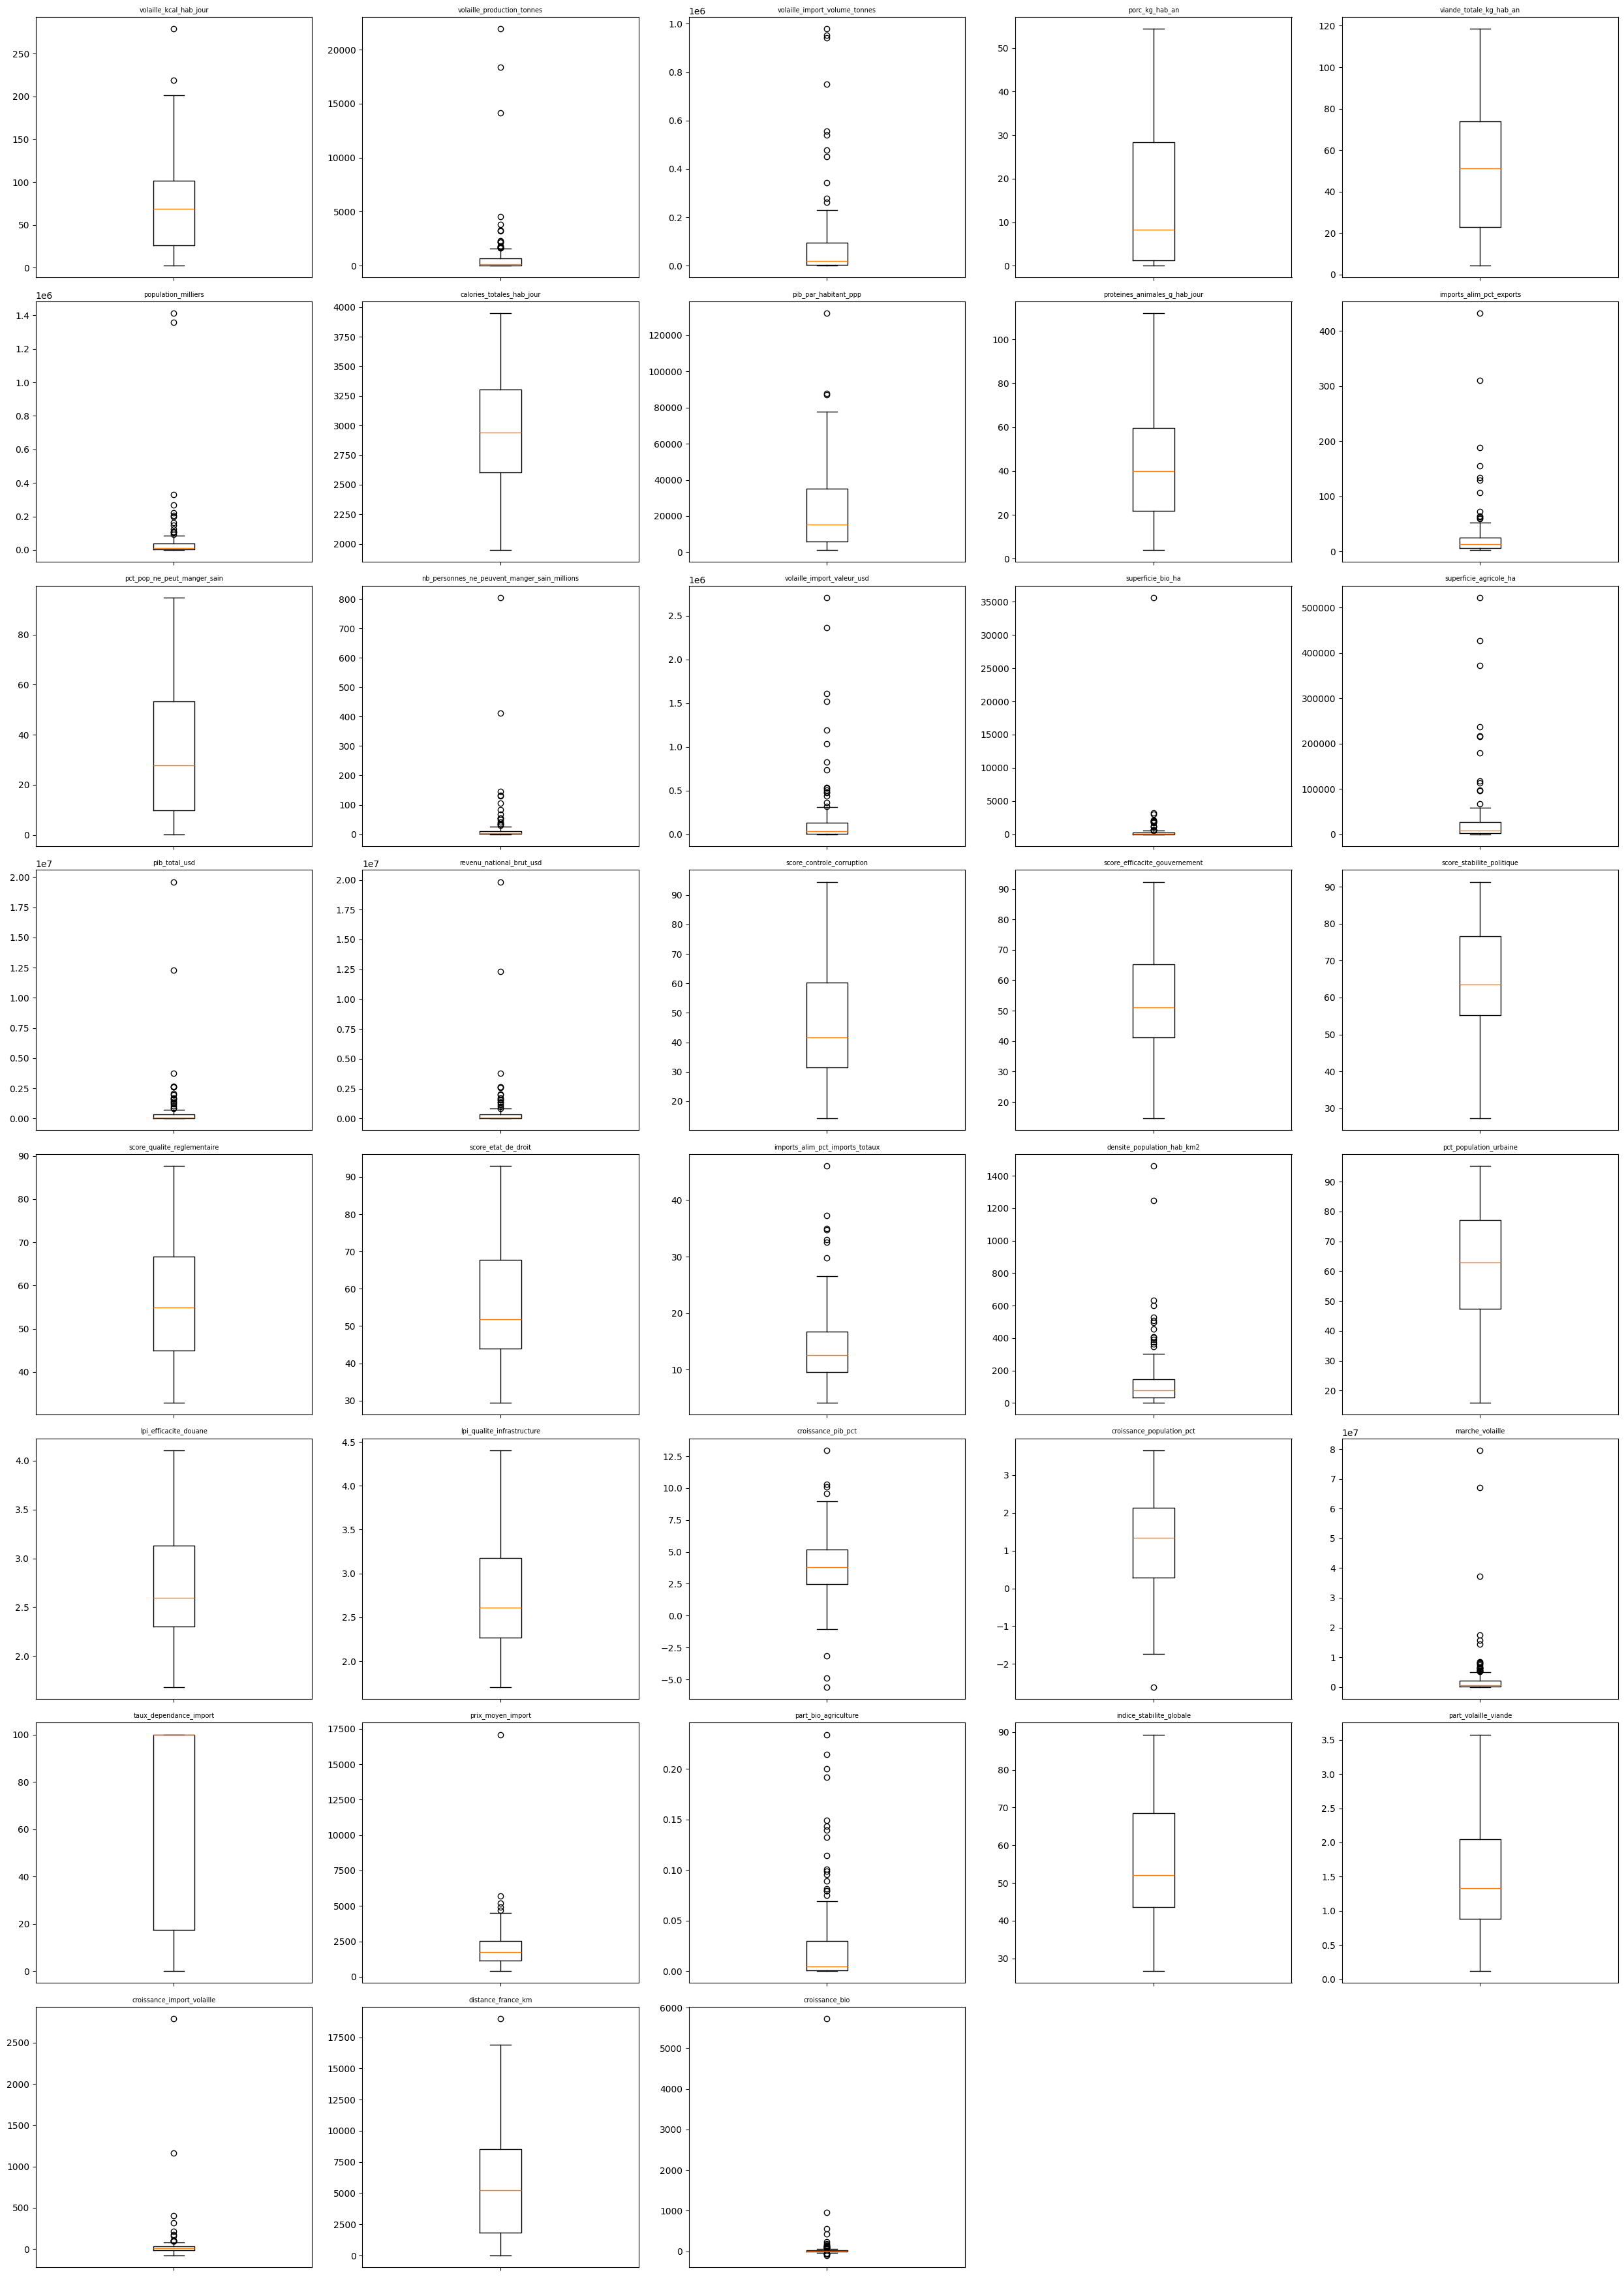

✅ Boxplots sauvegardés !


In [221]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables numériques uniquement
variables_num = df_final.drop(['pays', 'code_iso3'], axis=1).columns.tolist()

# Convertir toutes les colonnes en float
for col in variables_num:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

# Boxplots
fig, axes = plt.subplots(8, 5, figsize=(25, 35))
axes = axes.flatten()

for i, col in enumerate(variables_num):
    axes[i].boxplot(df_final[col].dropna())
    axes[i].set_title(col, fontsize=7)
    axes[i].tick_params(axis='x', labelbottom=False)

# Cacher les axes vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\boxplots_outliers.png", dpi=150)
plt.show()
print("✅ Boxplots sauvegardés !")

In [222]:
# Résumé statistique par variable avec détection outliers
from scipy import stats

print("=== RÉSUMÉ OUTLIERS PAR VARIABLE ===\n")

variables_num = df_final.drop(['pays', 'code_iso3'], axis=1).columns.tolist()

for col in variables_num:
    serie = df_final[col].dropna()
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    outliers = serie[(serie < Q1 - 1.5*IQR) | (serie > Q3 + 1.5*IQR)]
    print(f"{col}")
    print(f"  → Min: {serie.min():.2f} | Max: {serie.max():.2f} | Moyenne: {serie.mean():.2f} | {len(outliers)} outlier(s)")

=== RÉSUMÉ OUTLIERS PAR VARIABLE ===

volaille_kcal_hab_jour
  → Min: 2.33 | Max: 278.81 | Moyenne: 73.45 | 2 outlier(s)
volaille_production_tonnes
  → Min: 0.00 | Max: 21914.00 | Moyenne: 925.77 | 17 outlier(s)
volaille_import_volume_tonnes
  → Min: 13.12 | Max: 978091.13 | Moyenne: 90026.86 | 11 outlier(s)
porc_kg_hab_an
  → Min: 0.00 | Max: 54.37 | Moyenne: 15.09 | 0 outlier(s)
viande_totale_kg_hab_an
  → Min: 4.31 | Max: 118.43 | Moyenne: 49.95 | 0 outlier(s)
population_milliers
  → Min: 206.97 | Max: 1412354.73 | Moyenne: 54821.85 | 14 outlier(s)
calories_totales_hab_jour
  → Min: 1949.24 | Max: 3947.62 | Moyenne: 2950.04 | 0 outlier(s)
pib_par_habitant_ppp
  → Min: 1253.00 | Max: 132170.00 | Moyenne: 24576.43 | 3 outlier(s)
proteines_animales_g_hab_jour
  → Min: 4.00 | Max: 111.90 | Moyenne: 41.56 | 0 outlier(s)
imports_alim_pct_exports
  → Min: 3.00 | Max: 432.00 | Moyenne: 27.70 | 12 outlier(s)
pct_pop_ne_peut_manger_sain
  → Min: 0.30 | Max: 94.80 | Moyenne: 32.98 | 0 outlier(

In [223]:
# Résumé détaillé outliers par variable avec noms des pays
print("=== OUTLIERS DÉTAILLÉS PAR VARIABLE ===\n")

variables_num = df_final.drop(['pays', 'code_iso3'], axis=1).columns.tolist()

for col in variables_num:
    serie = df_final[col].dropna()
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5*IQR
    borne_sup = Q3 + 1.5*IQR
    
    outliers_df = df_final[
        (df_final[col] < borne_inf) | (df_final[col] > borne_sup)
    ][['pays', col]].sort_values(col, ascending=False)
    
    if len(outliers_df) > 0:
        print(f"📊 {col} ({len(outliers_df)} outlier(s)) — Bornes: [{borne_inf:.2f} ; {borne_sup:.2f}]")
        for _, row in outliers_df.iterrows():
            print(f"   - {row['pays']} : {row[col]:.2f}")
        print()

=== OUTLIERS DÉTAILLÉS PAR VARIABLE ===

📊 volaille_kcal_hab_jour (2 outlier(s)) — Bornes: [-87.75 ; 215.51]
   - Israel : 278.81
   - Trinidad and Tobago : 219.31

📊 volaille_production_tonnes (17 outlier(s)) — Bornes: [-916.50 ; 1615.50]
   - United States of America : 21914.00
   - China, mainland : 18405.00
   - Brazil : 14168.00
   - Russian Federation : 4542.00
   - India : 3804.00
   - Mexico : 3249.00
   - Indonesia : 3218.00
   - Poland : 2325.00
   - Iran (Islamic Republic of) : 2194.00
   - Türkiye : 2192.00
   - Argentina : 2162.00
   - United Kingdom of Great Britain and Northern Ireland : 1839.00
   - France : 1750.00
   - Myanmar : 1733.00
   - Thailand : 1703.00
   - Malaysia : 1665.00
   - South Africa : 1665.00

📊 volaille_import_volume_tonnes (11 outlier(s)) — Bornes: [-135290.88 ; 232806.40]
   - Mexico : 978091.13
   - United Kingdom of Great Britain and Northern Ireland : 951097.16
   - Germany : 941647.61
   - Netherlands (Kingdom of the) : 750287.87
   - South A

In [224]:
from sklearn.preprocessing import StandardScaler

# ============================================================
# STANDARDISATION Z-SCORE
# ============================================================

# Variables numériques uniquement (sans pays et code_iso3)
variables_num = df_final.drop(['pays', 'code_iso3'], axis=1).columns.tolist()

# Copie du dataset
df_scaled = df_final[['pays', 'code_iso3']].copy()

# Appliquer le Z-score
scaler = StandardScaler()
df_scaled_values = scaler.fit_transform(df_final[variables_num])

# Recréer le DataFrame
df_scaled[variables_num] = df_scaled_values

print("✅ Standardisation Z-score appliquée !")
print(f"Dimensions : {df_scaled.shape}")
print()
print("=== VÉRIFICATION (moyenne ≈ 0, écart-type ≈ 1) ===")
print(df_scaled[variables_num].describe().round(2).loc[['mean', 'std']].to_string())

✅ Standardisation Z-score appliquée !
Dimensions : (127, 40)

=== VÉRIFICATION (moyenne ≈ 0, écart-type ≈ 1) ===


      volaille_kcal_hab_jour  volaille_production_tonnes  volaille_import_volume_tonnes  porc_kg_hab_an  viande_totale_kg_hab_an  population_milliers  calories_totales_hab_jour  pib_par_habitant_ppp  proteines_animales_g_hab_jour  imports_alim_pct_exports  pct_pop_ne_peut_manger_sain  nb_personnes_ne_peuvent_manger_sain_millions  volaille_import_valeur_usd  superficie_bio_ha  superficie_agricole_ha  pib_total_usd  revenu_national_brut_usd  score_controle_corruption  score_efficacite_gouvernement  score_stabilite_politique  score_qualite_reglementaire  score_etat_de_droit  imports_alim_pct_imports_totaux  densite_population_hab_km2  pct_population_urbaine  lpi_efficacite_douane  lpi_qualite_infrastructure  croissance_pib_pct  croissance_population_pct  marche_volaille  taux_dependance_import  prix_moyen_import  part_bio_agriculture  indice_stabilite_globale  part_volaille_viande  croissance_import_volaille  distance_france_km  croissance_bio
mean                    -0.0                 

In [225]:
# Export du dataset standardisé
output_path_scaled = r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\DAN-P9-data\dataset_final_scaled.csv"

df_scaled.to_csv(output_path_scaled, index=False, encoding='utf-8-sig')

print(f"✅ Dataset standardisé exporté !")
print(f"Dimensions : {df_scaled.shape}")
print(f"Pays : {len(df_scaled)}")
print(f"Variables : {len(df_scaled.columns)}")

✅ Dataset standardisé exporté !
Dimensions : (127, 40)
Pays : 127
Variables : 40


In [226]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# EXPLORATION — STATS DESCRIPTIVES
# ============================================================

print("=== STATS DESCRIPTIVES — DATASET BRUT ===")
print(f"Pays : {len(df_final)}")
print(f"Variables : {len(df_final.columns) - 2}")
print()
print(df_final.drop(['pays', 'code_iso3'], axis=1).describe().round(2).to_string())

=== STATS DESCRIPTIVES — DATASET BRUT ===
Pays : 127
Variables : 38

       volaille_kcal_hab_jour  volaille_production_tonnes  volaille_import_volume_tonnes  porc_kg_hab_an  viande_totale_kg_hab_an  population_milliers  calories_totales_hab_jour  pib_par_habitant_ppp  proteines_animales_g_hab_jour  imports_alim_pct_exports  pct_pop_ne_peut_manger_sain  nb_personnes_ne_peuvent_manger_sain_millions  volaille_import_valeur_usd  superficie_bio_ha  superficie_agricole_ha  pib_total_usd  revenu_national_brut_usd  score_controle_corruption  score_efficacite_gouvernement  score_stabilite_politique  score_qualite_reglementaire  score_etat_de_droit  imports_alim_pct_imports_totaux  densite_population_hab_km2  pct_population_urbaine  lpi_efficacite_douane  lpi_qualite_infrastructure  croissance_pib_pct  croissance_population_pct  marche_volaille  taux_dependance_import  prix_moyen_import  part_bio_agriculture  indice_stabilite_globale  part_volaille_viande  croissance_import_volaille  distance_f

In [227]:
# Identifier les 3 pays avec NaN
pays_nan = df_final[df_final['nb_personnes_ne_peuvent_manger_sain_millions'].isna()]['pays'].tolist()
print("=== PAYS AVEC NaN ===")
print(pays_nan)

print()
# Chercher dans CoAHD pour ces pays
print("=== DONNÉES DISPONIBLES DANS CoAHD ===")
for pays in pays_nan:
    df_p = df_cost_clean[
        (df_cost_clean['Area'] == pays) &
        (df_cost_clean['Item'] == 'Number of people unable to afford a healthy diet (NUA), million') &
        (df_cost_clean['Release'] == 'July 2025 (SOFI report)')
    ]
    print(f"\n{pays} :")
    print(df_p[['Year', 'Value']].to_string())

=== PAYS AVEC NaN ===
['Malta', 'Iceland', 'Luxembourg']

=== DONNÉES DISPONIBLES DANS CoAHD ===

Malta :
      Year Value
5886  2017  <0.1
5888  2018  <0.1
5890  2019  <0.1
5892  2020  <0.1
5894  2021  <0.1
5896  2022  <0.1
5898  2023  <0.1
5899  2024  <0.1

Iceland :
      Year Value
4350  2017  <0.1
4352  2018  <0.1
4354  2019  <0.1
4356  2020  <0.1
4358  2021  <0.1
4360  2022  <0.1
4362  2023  <0.1
4363  2024  <0.1

Luxembourg :
      Year Value
5550  2017  <0.1
5552  2018  <0.1
5554  2019  <0.1
5556  2020  <0.1
5558  2021  <0.1
5560  2022  <0.1
5562  2023  <0.1
5563  2024  <0.1


In [228]:
# Imputer Luxembourg, Malta, Iceland à 0.05
pays_moins_01 = ['Luxembourg', 'Malta', 'Iceland']

df_final.loc[df_final['pays'].isin(pays_moins_01), 'nb_personnes_ne_peuvent_manger_sain_millions'] = 0.05

# Vérifier
print("=== APRÈS IMPUTATION ===")
print(f"NaN restants : {df_final['nb_personnes_ne_peuvent_manger_sain_millions'].isna().sum()}")
print()
print(df_final[df_final['pays'].isin(pays_moins_01)][['pays', 'nb_personnes_ne_peuvent_manger_sain_millions']].to_string())

=== APRÈS IMPUTATION ===
NaN restants : 0

          pays  nb_personnes_ne_peuvent_manger_sain_millions
72       Malta                                          0.05
74     Iceland                                          0.05
95  Luxembourg                                          0.05


In [229]:
# Restandardiser après correction
from sklearn.preprocessing import StandardScaler

variables_num = df_final.drop(['pays', 'code_iso3'], axis=1).columns.tolist()

# Convertir en numérique
for col in variables_num:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

# Recréer df_scaled
df_scaled = df_final[['pays', 'code_iso3']].copy()
scaler = StandardScaler()
df_scaled[variables_num] = scaler.fit_transform(df_final[variables_num])

print("✅ Dataset restandardisé !")
print(f"NaN total : {df_scaled.isnull().sum().sum()}")

# Réexporter les deux datasets
df_final.to_csv(r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\DAN-P9-data\dataset_final_v2.csv", index=False, encoding='utf-8-sig')
df_scaled.to_csv(r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\DAN-P9-data\dataset_final_scaled.csv", index=False, encoding='utf-8-sig')

print("✅ Les deux datasets exportés !")

✅ Dataset restandardisé !
NaN total : 0
✅ Les deux datasets exportés !


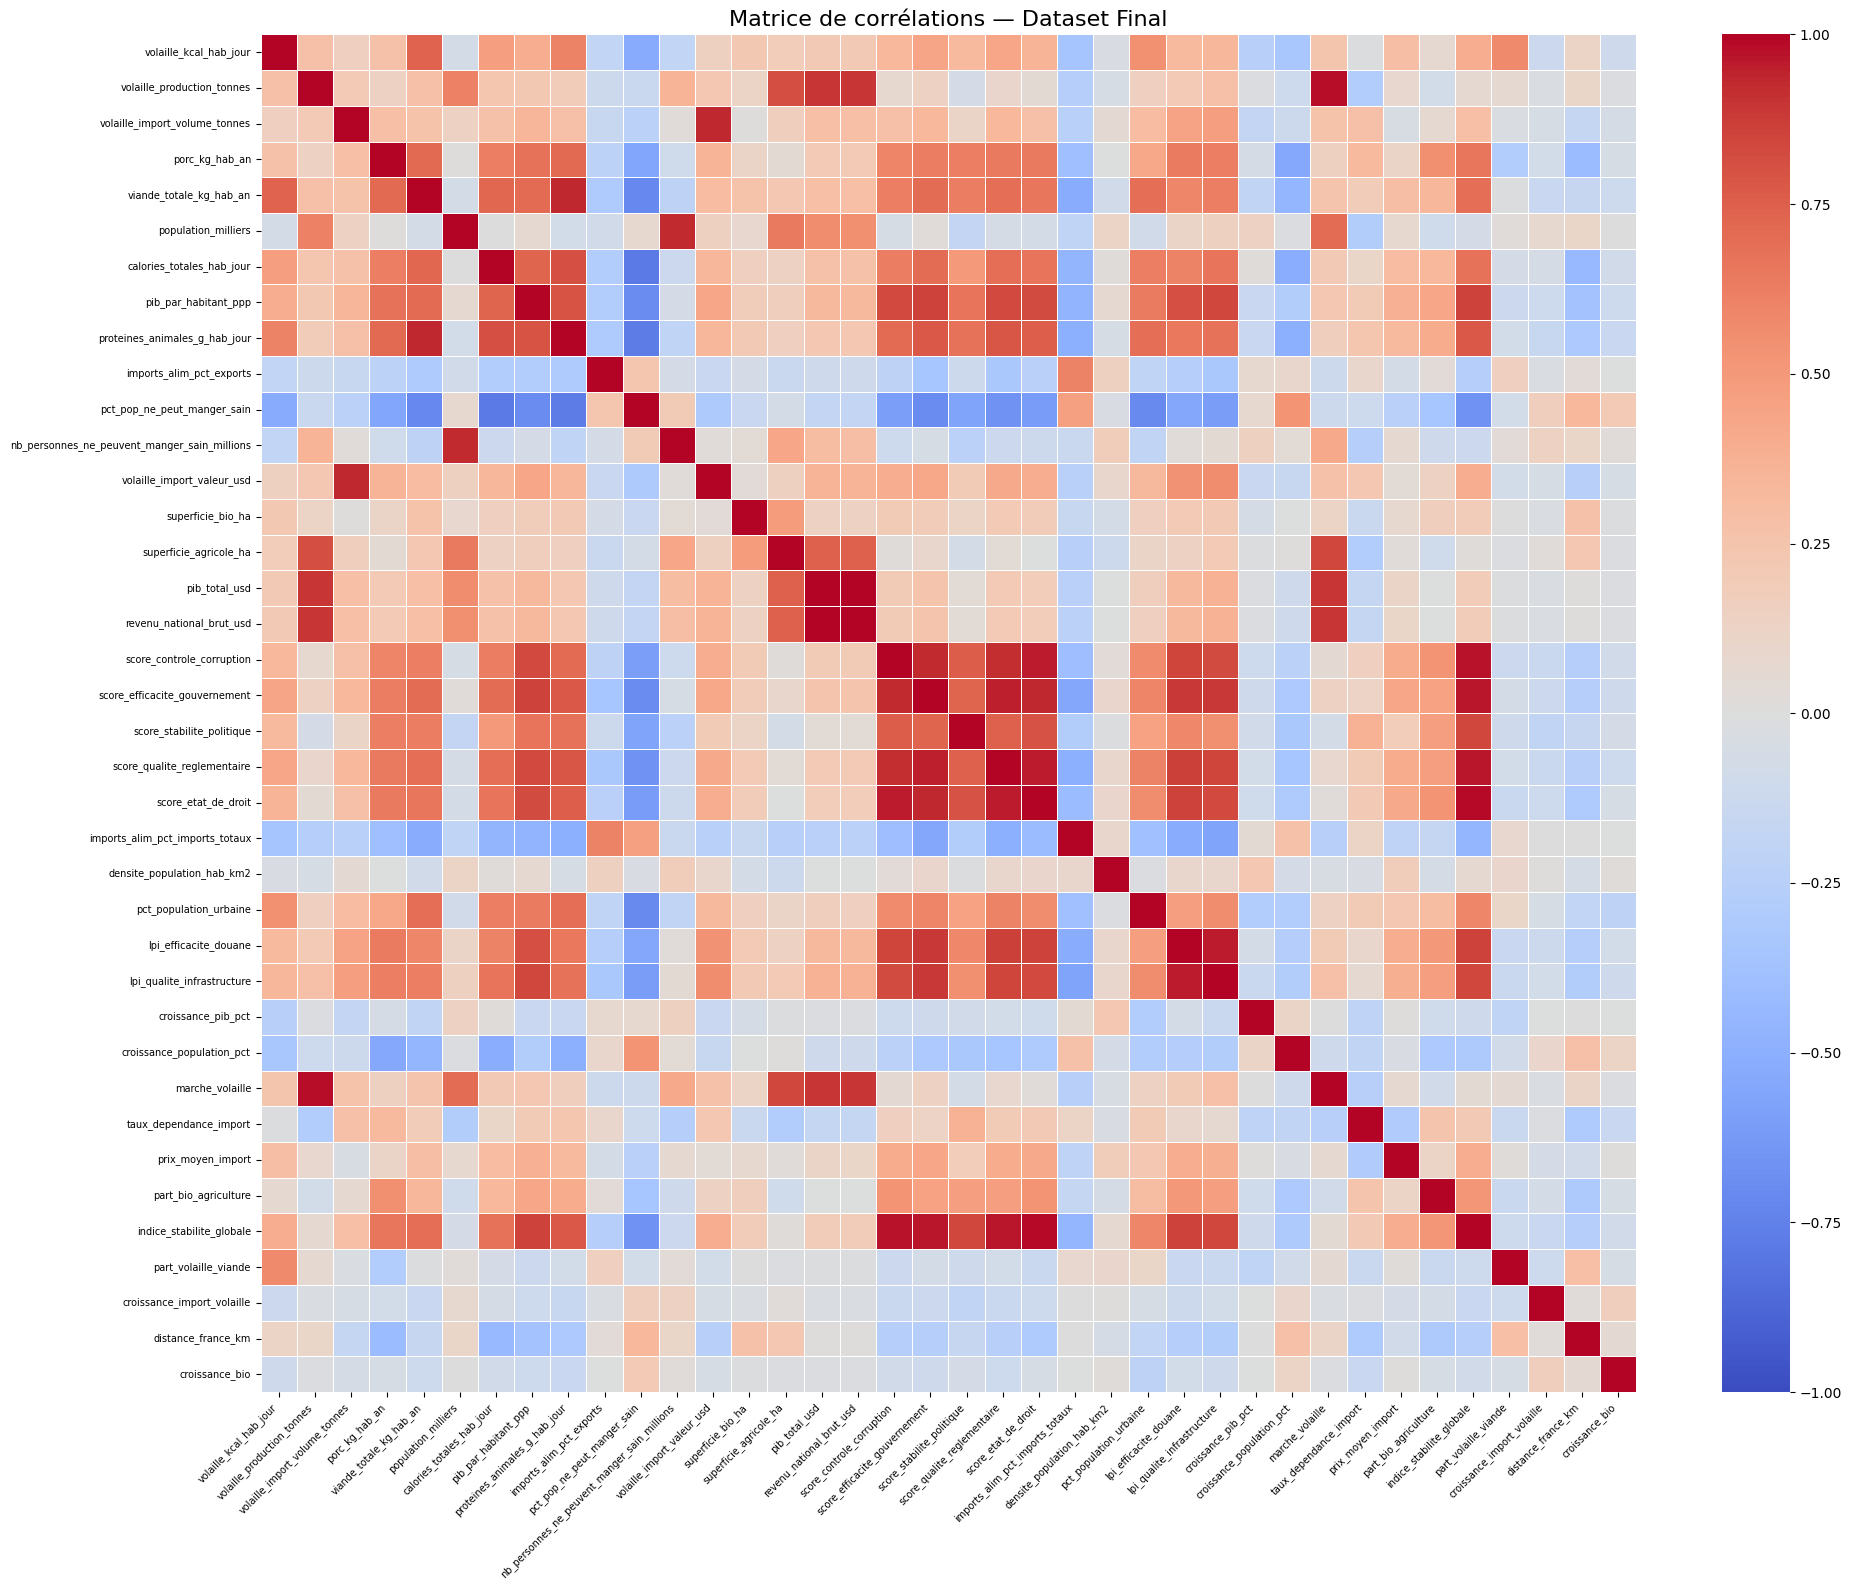

✅ Matrice de corrélations sauvegardée !


In [230]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# MATRICE DE CORRÉLATIONS
# ============================================================

variables_num = df_final.drop(['pays', 'code_iso3'], axis=1).columns.tolist()

# Calculer la matrice de corrélation
corr_matrix = df_final[variables_num].corr()

# Visualiser
plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Matrice de corrélations — Dataset Final', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\matrice_correlations.png", dpi=150)
plt.show()
print("✅ Matrice de corrélations sauvegardée !")

In [231]:
# ============================================================
# CORRÉLATIONS PAR SEUIL
# ============================================================

variables_num = df_final.drop(['pays', 'code_iso3'], axis=1).columns.tolist()
corr_matrix = df_final[variables_num].corr().abs()

for seuil in [0.95, 0.90, 0.85]:
    print(f"\n=== PAIRES AVEC CORRÉLATION > {seuil} ===\n")
    count = 0
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > seuil:
                var1 = corr_matrix.columns[i]
                var2 = corr_matrix.columns[j]
                corr_val = corr_matrix.iloc[i, j]
                print(f"  {var1} ↔ {var2} : {corr_val:.3f}")
                count += 1
    print(f"Total : {count} paires")



=== PAIRES AVEC CORRÉLATION > 0.95 ===

  volaille_production_tonnes ↔ marche_volaille : 0.978
  pib_total_usd ↔ revenu_national_brut_usd : 1.000
  score_controle_corruption ↔ score_etat_de_droit : 0.961
  score_controle_corruption ↔ indice_stabilite_globale : 0.971
  score_efficacite_gouvernement ↔ indice_stabilite_globale : 0.964
  score_qualite_reglementaire ↔ score_etat_de_droit : 0.955
  score_qualite_reglementaire ↔ indice_stabilite_globale : 0.967
  score_etat_de_droit ↔ indice_stabilite_globale : 0.984
  lpi_efficacite_douane ↔ lpi_qualite_infrastructure : 0.959
Total : 9 paires

=== PAIRES AVEC CORRÉLATION > 0.9 ===

  volaille_production_tonnes ↔ marche_volaille : 0.978
  volaille_import_volume_tonnes ↔ volaille_import_valeur_usd : 0.934
  viande_totale_kg_hab_an ↔ proteines_animales_g_hab_jour : 0.933
  population_milliers ↔ nb_personnes_ne_peuvent_manger_sain_millions : 0.924
  pib_total_usd ↔ revenu_national_brut_usd : 1.000
  score_controle_corruption ↔ score_efficacite_

In [232]:
# ============================================================
# SUPPRESSION DES VARIABLES REDONDANTES (corrélation > 0.90)
# ============================================================

variables_a_virer = [
    'revenu_national_brut_usd',
    'volaille_production_tonnes',
    'score_controle_corruption',
    'score_efficacite_gouvernement',
    'score_qualite_reglementaire',
    'score_etat_de_droit',
    'score_stabilite_politique',
    'lpi_qualite_infrastructure',
    'volaille_import_volume_tonnes',
    'proteines_animales_g_hab_jour',
    'nb_personnes_ne_peuvent_manger_sain_millions'
]

df_final = df_final.drop(variables_a_virer, axis=1)

print(f"✅ {len(variables_a_virer)} variables supprimées")
print(f"Dimensions : {df_final.shape}")
print()
print("=== VARIABLES RESTANTES ===")
for i, col in enumerate(df_final.columns):
    print(f"{i+1}. {col}")

✅ 11 variables supprimées
Dimensions : (127, 29)

=== VARIABLES RESTANTES ===
1. pays
2. code_iso3
3. volaille_kcal_hab_jour
4. porc_kg_hab_an
5. viande_totale_kg_hab_an
6. population_milliers
7. calories_totales_hab_jour
8. pib_par_habitant_ppp
9. imports_alim_pct_exports
10. pct_pop_ne_peut_manger_sain
11. volaille_import_valeur_usd
12. superficie_bio_ha
13. superficie_agricole_ha
14. pib_total_usd
15. imports_alim_pct_imports_totaux
16. densite_population_hab_km2
17. pct_population_urbaine
18. lpi_efficacite_douane
19. croissance_pib_pct
20. croissance_population_pct
21. marche_volaille
22. taux_dependance_import
23. prix_moyen_import
24. part_bio_agriculture
25. indice_stabilite_globale
26. part_volaille_viande
27. croissance_import_volaille
28. distance_france_km
29. croissance_bio


In [233]:
# ============================================================
# RESTANDARDISATION ET EXPORT FINAL
# ============================================================

variables_num = df_final.drop(['pays', 'code_iso3'], axis=1).columns.tolist()

# Convertir en numérique
for col in variables_num:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

# Restandardiser
df_scaled = df_final[['pays', 'code_iso3']].copy()
scaler = StandardScaler()
df_scaled[variables_num] = scaler.fit_transform(df_final[variables_num])

print("✅ Restandardisation appliquée !")
print(f"Dimensions : {df_scaled.shape}")
print(f"NaN total : {df_scaled.isnull().sum().sum()}")

# Export
df_final.to_csv(r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\DAN-P9-data\dataset_final_v3.csv", index=False, encoding='utf-8-sig')
df_scaled.to_csv(r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\DAN-P9-data\dataset_final_scaled_v3.csv", index=False, encoding='utf-8-sig')

✅ Restandardisation appliquée !
Dimensions : (127, 29)
NaN total : 0


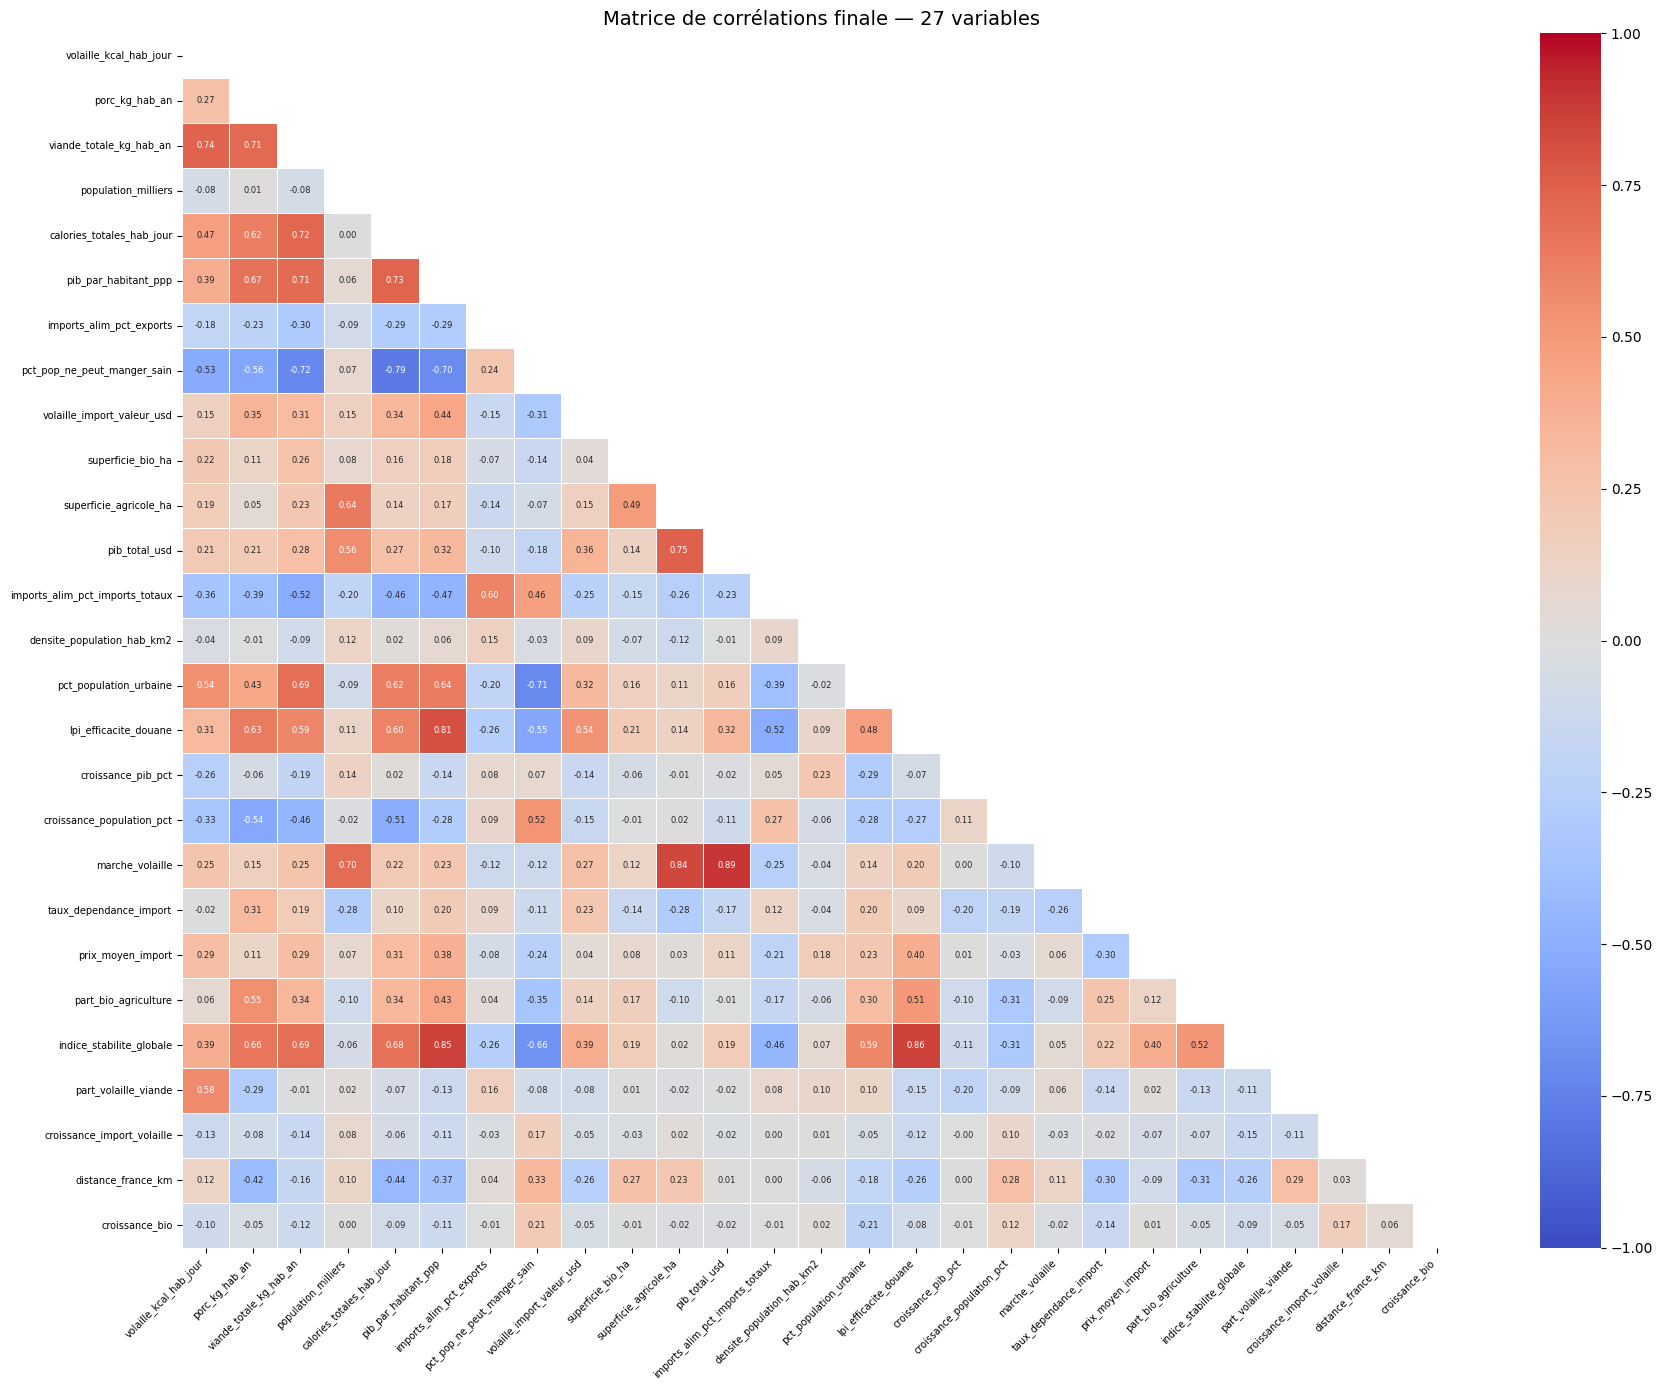

✅ Demi matrice sauvegardée !


In [234]:
# ============================================================
# MATRICE DE CORRÉLATIONS FINALE — DEMI MATRICE
# ============================================================

variables_num = df_final.drop(['pays', 'code_iso3'], axis=1).columns.tolist()
corr_matrix = df_final[variables_num].corr()

# Masque pour la demi matrice
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={'size': 6}
)
plt.title('Matrice de corrélations finale — 27 variables', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\matrice_correlations_demi.png", dpi=150)
plt.show()
print("✅ Demi matrice sauvegardée !")

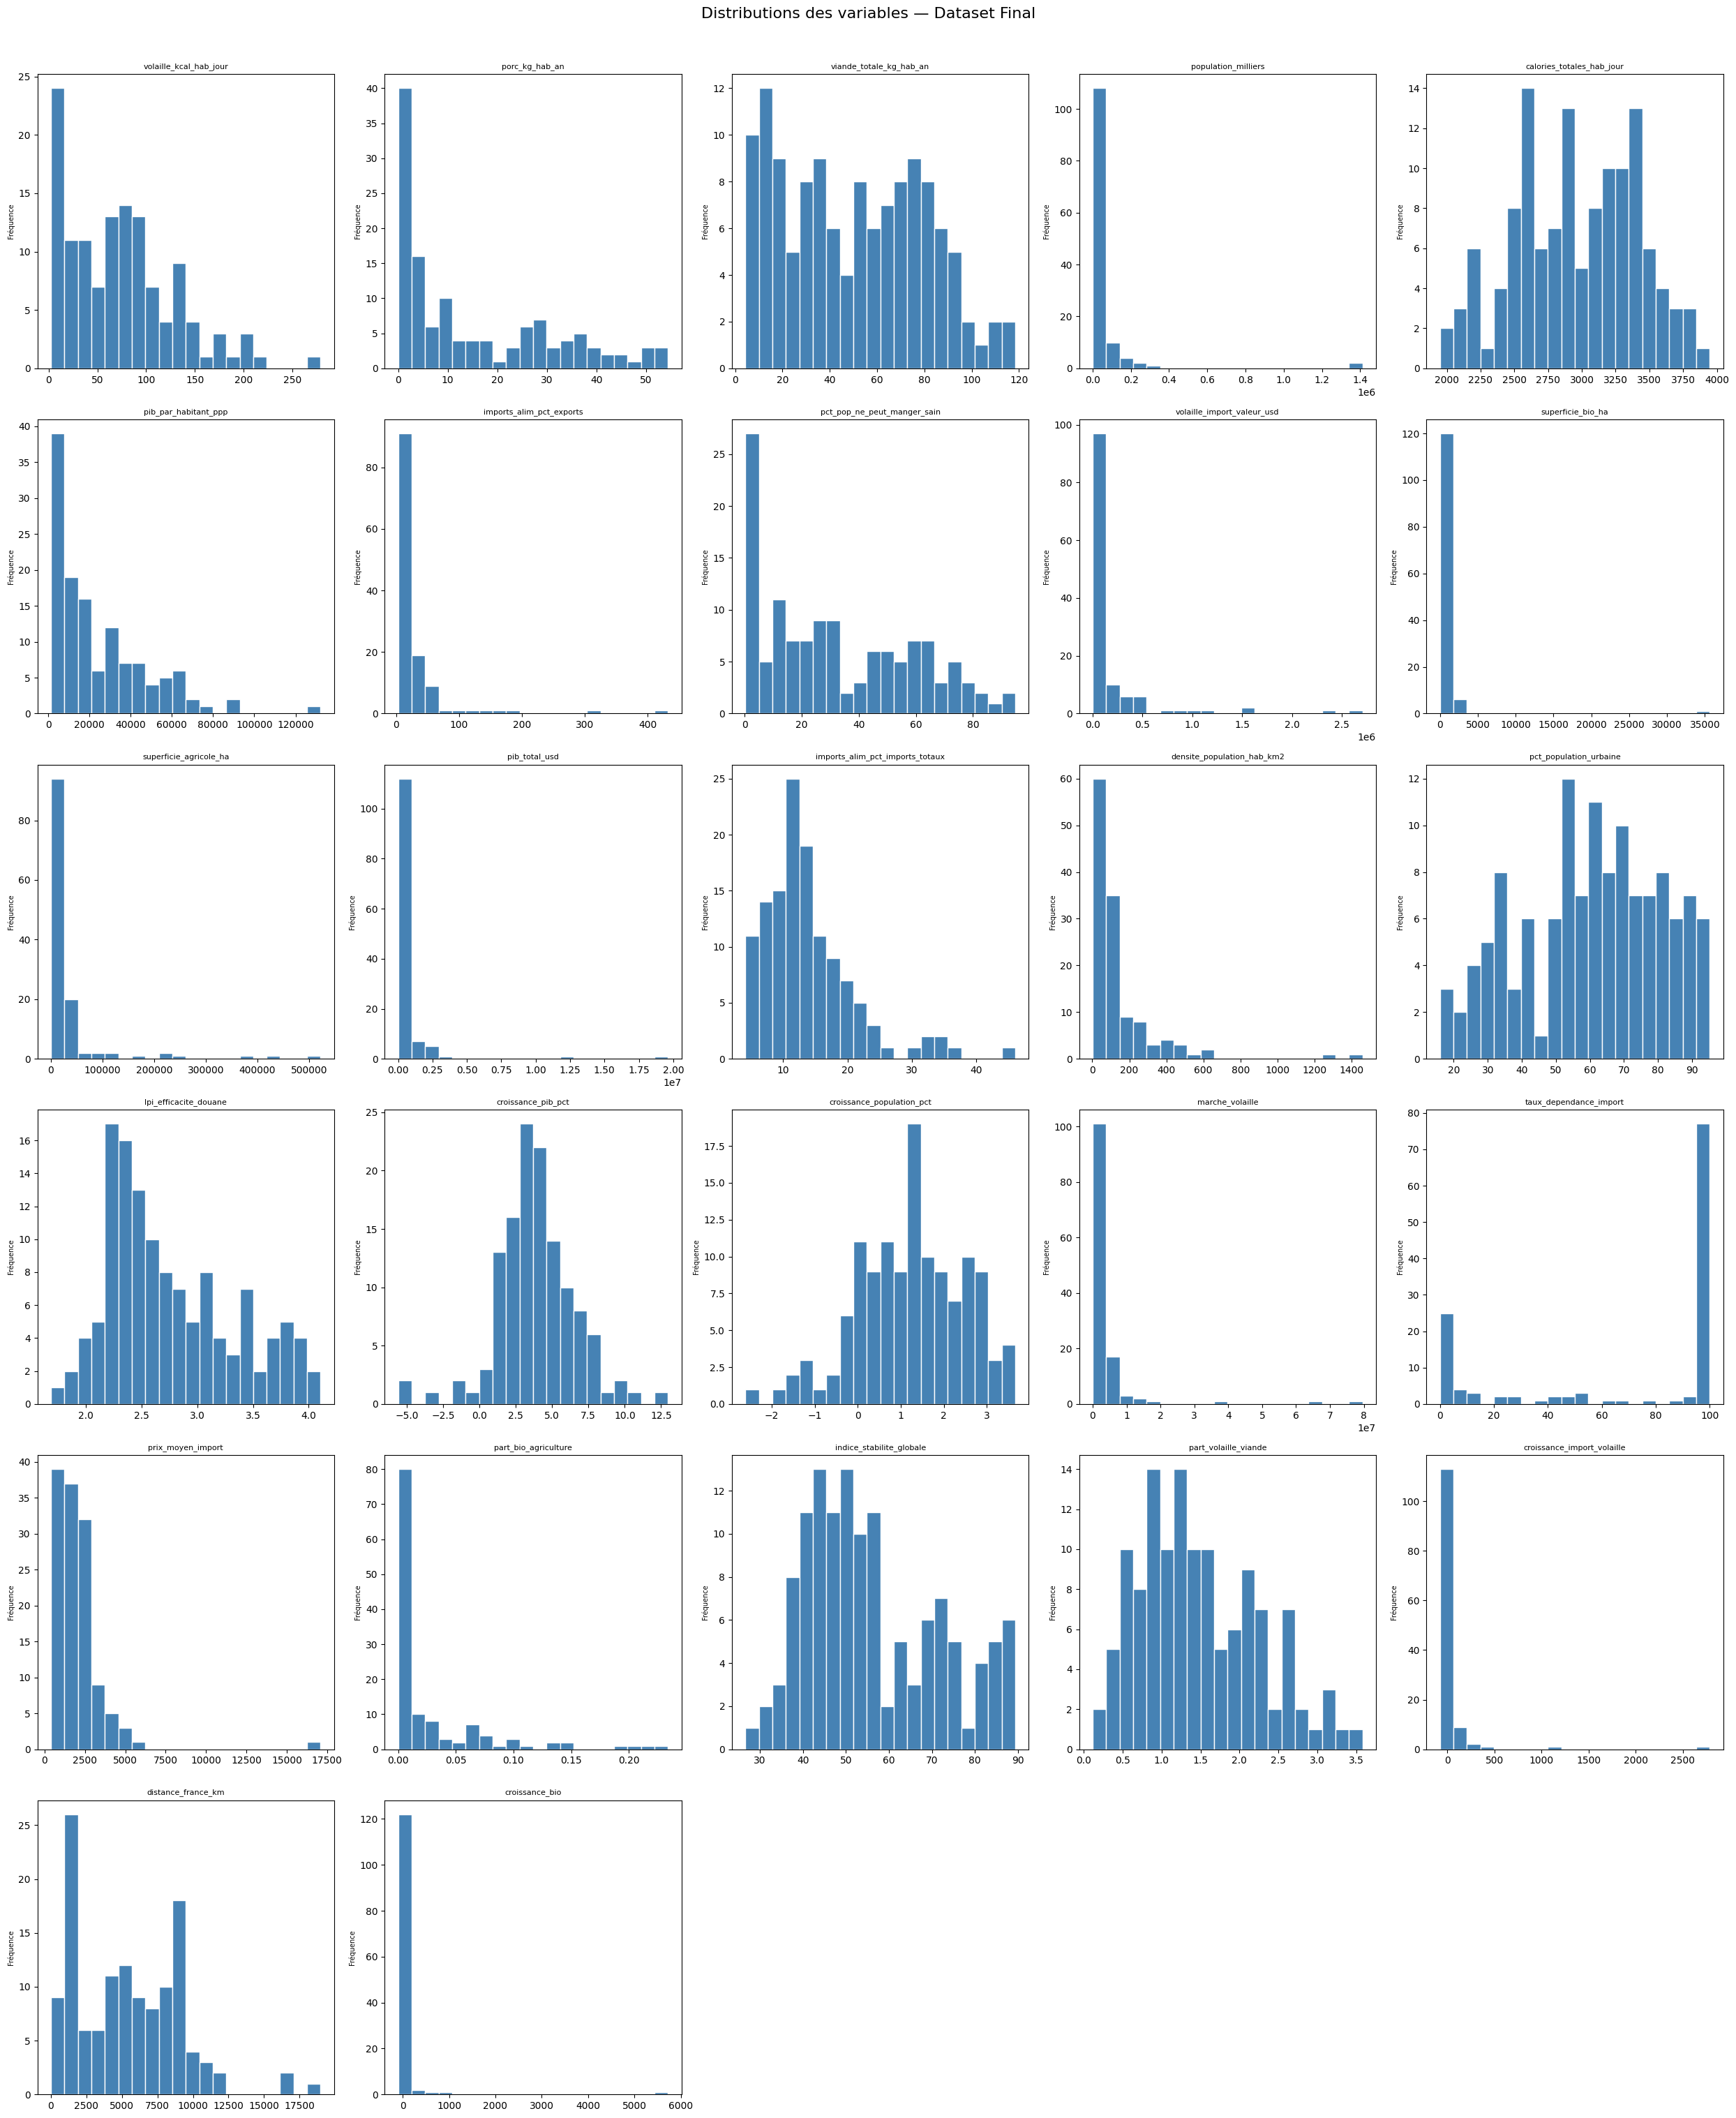

✅ Distributions sauvegardées !


In [235]:
# ============================================================
# DISTRIBUTIONS — HISTOGRAMMES
# ============================================================

variables_num = df_final.drop(['pays', 'code_iso3'], axis=1).columns.tolist()

fig, axes = plt.subplots(6, 5, figsize=(25, 30))
axes = axes.flatten()

for i, col in enumerate(variables_num):
    axes[i].hist(df_final[col].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Fréquence', fontsize=7)

# Cacher les axes vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions des variables — Dataset Final', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\distributions.png", dpi=150)
plt.show()
print("✅ Distributions sauvegardées !")

In [236]:
# Suppression viande_totale_kg_hab_an
df_final = df_final.drop('viande_totale_kg_hab_an', axis=1)
df_scaled = df_scaled.drop('viande_totale_kg_hab_an', axis=1)

print(f"✅ viande_totale_kg_hab_an supprimée")
print(f"Dimensions : {df_final.shape}")

✅ viande_totale_kg_hab_an supprimée
Dimensions : (127, 28)


In [237]:
# Suppression pib_total_usd
df_final = df_final.drop('pib_total_usd', axis=1)
df_scaled = df_scaled.drop('pib_total_usd', axis=1)

print(f"✅ pib_total_usd supprimé")
print(f"Dimensions : {df_final.shape}")
print()
print("=== VARIABLES RESTANTES ===")
for i, col in enumerate(df_final.columns):
    print(f"{i+1}. {col}")

✅ pib_total_usd supprimé
Dimensions : (127, 27)

=== VARIABLES RESTANTES ===
1. pays
2. code_iso3
3. volaille_kcal_hab_jour
4. porc_kg_hab_an
5. population_milliers
6. calories_totales_hab_jour
7. pib_par_habitant_ppp
8. imports_alim_pct_exports
9. pct_pop_ne_peut_manger_sain
10. volaille_import_valeur_usd
11. superficie_bio_ha
12. superficie_agricole_ha
13. imports_alim_pct_imports_totaux
14. densite_population_hab_km2
15. pct_population_urbaine
16. lpi_efficacite_douane
17. croissance_pib_pct
18. croissance_population_pct
19. marche_volaille
20. taux_dependance_import
21. prix_moyen_import
22. part_bio_agriculture
23. indice_stabilite_globale
24. part_volaille_viande
25. croissance_import_volaille
26. distance_france_km
27. croissance_bio


In [238]:
# Suppression porc_kg_hab_an
df_final = df_final.drop('porc_kg_hab_an', axis=1)
df_scaled = df_scaled.drop('porc_kg_hab_an', axis=1)

print(f"✅ porc_kg_hab_an supprimée")
print(f"Dimensions : {df_final.shape}")

✅ porc_kg_hab_an supprimée
Dimensions : (127, 26)


In [239]:
# Suppression superficie_agricole_ha et superficie_bio_ha
df_final = df_final.drop(['superficie_agricole_ha', 'superficie_bio_ha'], axis=1)
df_scaled = df_scaled.drop(['superficie_agricole_ha', 'superficie_bio_ha'], axis=1)

print(f"✅ superficie_agricole_ha et superficie_bio_ha supprimées")
print(f"Dimensions : {df_final.shape}")
print()
print("=== VARIABLES RESTANTES ===")
for i, col in enumerate(df_final.columns):
    print(f"{i+1}. {col}")

✅ superficie_agricole_ha et superficie_bio_ha supprimées
Dimensions : (127, 24)

=== VARIABLES RESTANTES ===
1. pays
2. code_iso3
3. volaille_kcal_hab_jour
4. population_milliers
5. calories_totales_hab_jour
6. pib_par_habitant_ppp
7. imports_alim_pct_exports
8. pct_pop_ne_peut_manger_sain
9. volaille_import_valeur_usd
10. imports_alim_pct_imports_totaux
11. densite_population_hab_km2
12. pct_population_urbaine
13. lpi_efficacite_douane
14. croissance_pib_pct
15. croissance_population_pct
16. marche_volaille
17. taux_dependance_import
18. prix_moyen_import
19. part_bio_agriculture
20. indice_stabilite_globale
21. part_volaille_viande
22. croissance_import_volaille
23. distance_france_km
24. croissance_bio


In [240]:
# ============================================================
# SUPPRESSION croissance_bio et croissance_import_volaille
# ============================================================

df_final = df_final.drop(['croissance_bio', 'croissance_import_volaille'], axis=1)

print(f"✅ 2 variables supprimées")
print(f"Dimensions : {df_final.shape}")
print()
print("=== VARIABLES RESTANTES ===")
for i, col in enumerate(df_final.columns):
    print(f"{i+1}. {col}")

✅ 2 variables supprimées
Dimensions : (127, 22)

=== VARIABLES RESTANTES ===
1. pays
2. code_iso3
3. volaille_kcal_hab_jour
4. population_milliers
5. calories_totales_hab_jour
6. pib_par_habitant_ppp
7. imports_alim_pct_exports
8. pct_pop_ne_peut_manger_sain
9. volaille_import_valeur_usd
10. imports_alim_pct_imports_totaux
11. densite_population_hab_km2
12. pct_population_urbaine
13. lpi_efficacite_douane
14. croissance_pib_pct
15. croissance_population_pct
16. marche_volaille
17. taux_dependance_import
18. prix_moyen_import
19. part_bio_agriculture
20. indice_stabilite_globale
21. part_volaille_viande
22. distance_france_km


In [243]:
# Supprimer la France du dataset
df_final = df_final[df_final['pays'] != 'France']
df_scaled = df_scaled[df_scaled['pays'] != 'France']

print(f"✅ France supprimée !")
print(f"Pays restants : {len(df_final)}")

# Réexporter
df_final.to_csv(r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\DAN-P9-data\dataset_final_v4.csv", index=False, encoding='utf-8-sig')
df_scaled.to_csv(r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\DAN-P9-data\dataset_final_scaled_v4.csv", index=False, encoding='utf-8-sig')

print("✅ Datasets réexportés !")

✅ France supprimée !
Pays restants : 126
✅ Datasets réexportés !


In [248]:
print("=== VARIABLES ACTUELLES ===")
for i, col in enumerate(df_final.columns):
    print(f"{i+1}. {col}")

=== VARIABLES ACTUELLES ===
1. pays
2. code_iso3
3. volaille_kcal_hab_jour
4. population_milliers
5. pib_par_habitant_ppp
6. pct_pop_ne_peut_manger_sain
7. volaille_import_valeur_usd
8. imports_alim_pct_imports_totaux
9. densite_population_hab_km2
10. pct_population_urbaine
11. lpi_efficacite_douane
12. croissance_pib_pct
13. marche_volaille
14. taux_dependance_import
15. prix_moyen_import
16. part_bio_agriculture
17. indice_stabilite_globale
18. part_volaille_viande
19. distance_france_km


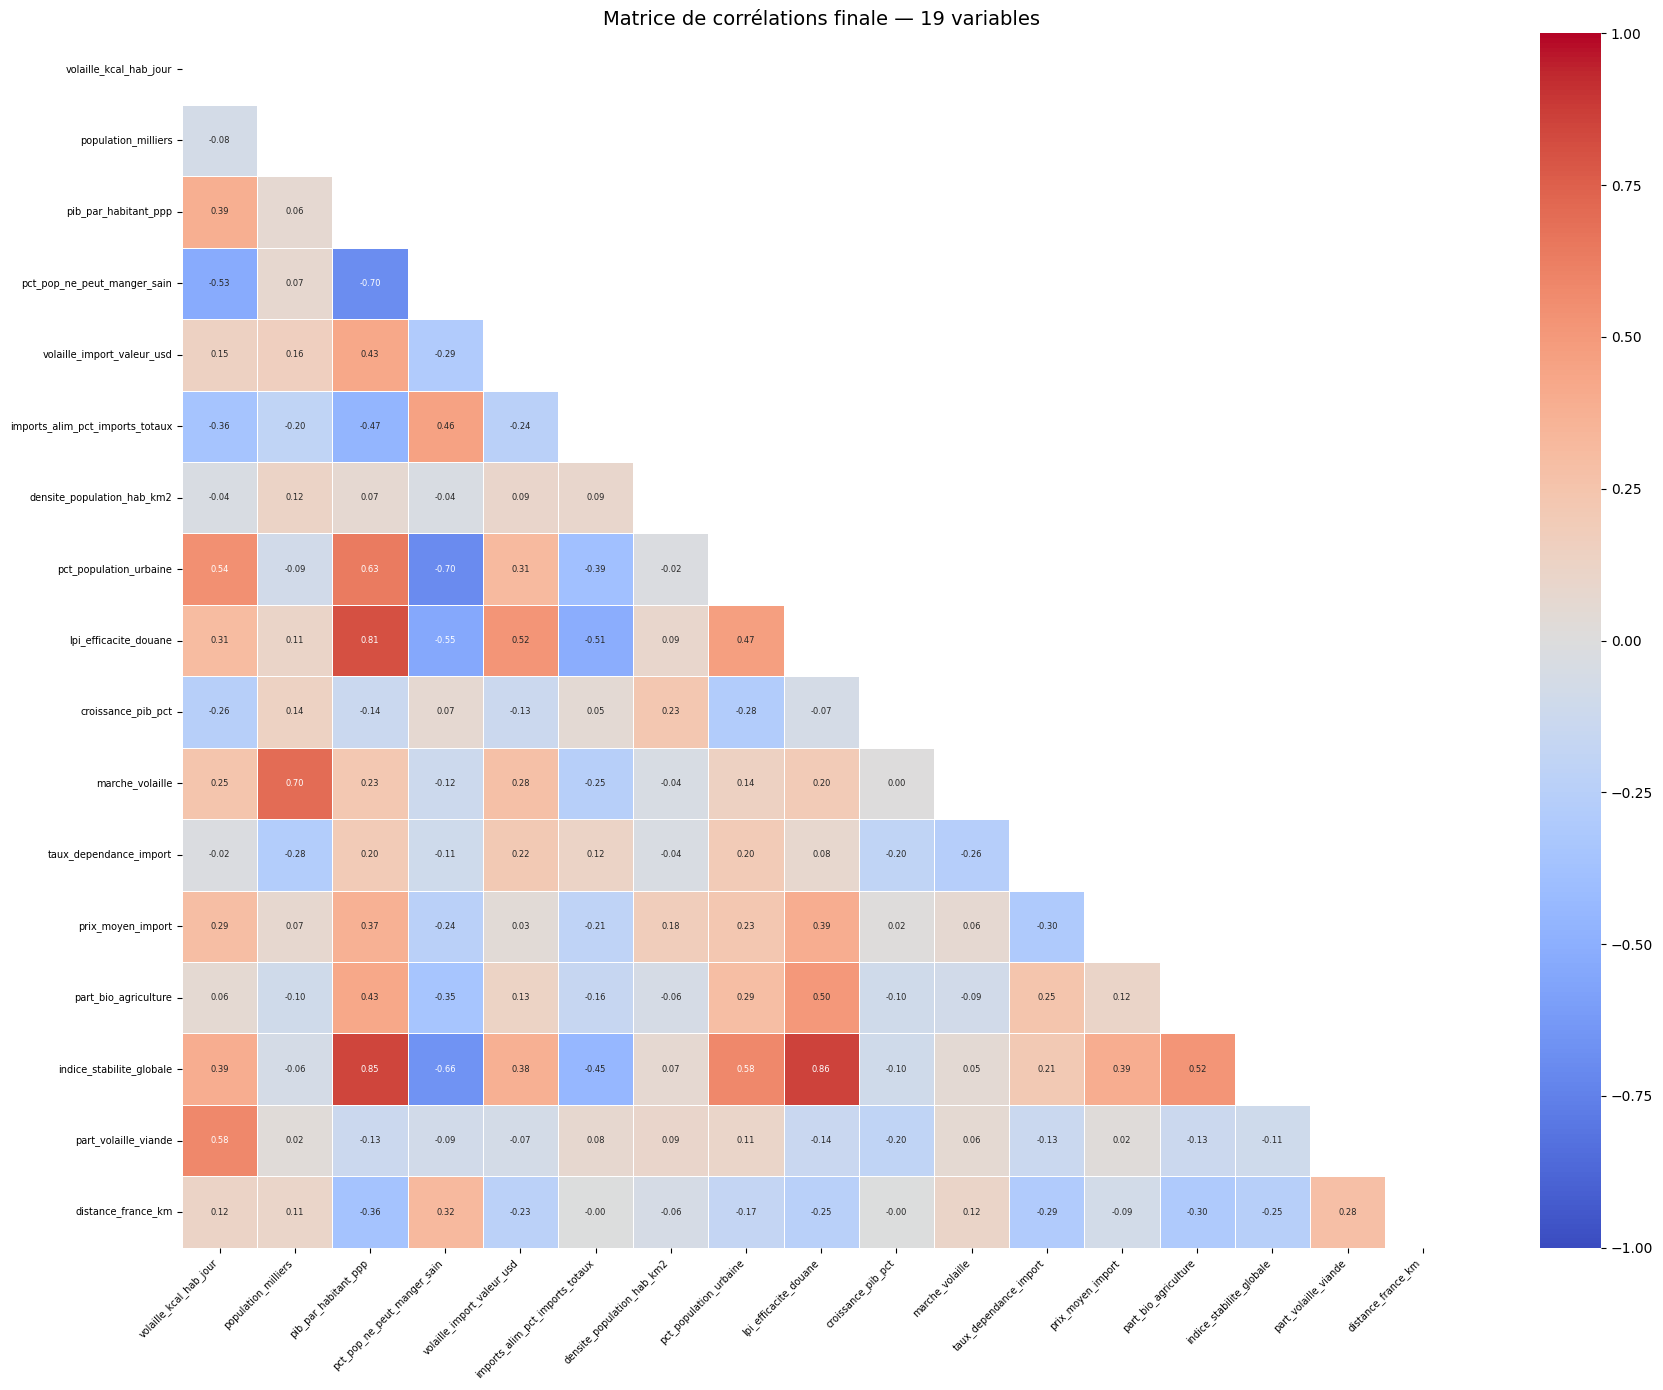

✅ Demi matrice sauvegardée !


In [249]:
# ============================================================
# MATRICE DE CORRÉLATIONS FINALE — DEMI MATRICE
# ============================================================

variables_num = df_final.drop(['pays', 'code_iso3'], axis=1).columns.tolist()
corr_matrix = df_final[variables_num].corr()

# Masque pour la demi matrice
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={'size': 6}
)
plt.title('Matrice de corrélations finale — 19 variables', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\matrice_correlations_demi.png", dpi=150)
plt.show()
print("✅ Demi matrice sauvegardée !")

In [252]:
# ============================================================
# TRANSFORMATION volaille_import_valeur_usd en par habitant
# ============================================================

df_final['volaille_import_valeur_usd_hab'] = df_final['volaille_import_valeur_usd'] / df_final['population_milliers']

# Virer l'ancienne variable
df_final = df_final.drop('volaille_import_valeur_usd', axis=1)

print("✅ volaille_import_valeur_usd_hab créée")
print(f"Min : {df_final['volaille_import_valeur_usd_hab'].min():.4f}")
print(f"Max : {df_final['volaille_import_valeur_usd_hab'].max():.4f}")
print(f"Moyenne : {df_final['volaille_import_valeur_usd_hab'].mean():.4f}")
print()
print(f"Dimensions : {df_final.shape}")

✅ volaille_import_valeur_usd_hab créée
Min : 0.0004
Max : 104.5517
Moyenne : 12.4962

Dimensions : (126, 19)


In [254]:
# ============================================================
# EXPORT FINAL V6 — 17 VARIABLES PROPRES
# ============================================================

from sklearn.preprocessing import StandardScaler

variables_num = df_final.drop(['pays', 'code_iso3'], axis=1).columns.tolist()

for col in variables_num:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

df_scaled = df_final[['pays', 'code_iso3']].copy()
scaler = StandardScaler()
df_scaled[variables_num] = scaler.fit_transform(df_final[variables_num])

df_final.to_csv(r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\DAN-P9-data\dataset_final_v6.csv", index=False, encoding='utf-8-sig')
df_scaled.to_csv(r"C:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P11 GLOBAL\DAN-P9-data\dataset_final_scaled_v6.csv", index=False, encoding='utf-8-sig')

print("✅ Export final v6 !")
print(f"Pays : {len(df_final)}")
print(f"Variables : {len(variables_num)}")
print()
for i, col in enumerate(variables_num):
    print(f"{i+1}. {col}")

✅ Export final v6 !
Pays : 126
Variables : 17

1. volaille_kcal_hab_jour
2. population_milliers
3. pib_par_habitant_ppp
4. pct_pop_ne_peut_manger_sain
5. imports_alim_pct_imports_totaux
6. densite_population_hab_km2
7. pct_population_urbaine
8. lpi_efficacite_douane
9. croissance_pib_pct
10. marche_volaille
11. taux_dependance_import
12. prix_moyen_import
13. part_bio_agriculture
14. indice_stabilite_globale
15. part_volaille_viande
16. distance_france_km
17. volaille_import_valeur_usd_hab
